In [1]:
!pip install missingno 

In [52]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 
import missingno as msno
import re
import os 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Loading the data set

In [3]:
d=pd.read_csv(r"C:\Users\Rithish\Downloads\mobiles1.csv")

### Data Understanding

In [4]:
d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 984 entries, 0 to 983
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   battery    984 non-null    object 
 1   camera     984 non-null    object 
 2   display    984 non-null    object 
 3   memory     984 non-null    object 
 4   name       984 non-null    object 
 5   price      984 non-null    int64  
 6   processor  983 non-null    object 
 7   rating     971 non-null    float64
 8   reviews    971 non-null    object 
 9   warranty   836 non-null    object 
dtypes: float64(1), int64(1), object(8)
memory usage: 77.0+ KB


In [5]:
d.head(1)

,battery,camera,display,memory,name,price,processor,rating,reviews,warranty
0,5000 mAh Battery,12MP + 2MP | 8MP Front Camera,15.8 cm (6.22 inch) HD+ Display,4 GB RAM | 64 GB ROM | Expandable Upto 512 GB,"Redmi 8 (Ruby Red, 64 GB)",9999,Qualcomm Snapdragon 439 Processor,4.4,"55,078 Reviews",Brand Warranty of 1 Year Available for Mobile ...


In [6]:
d.shape

(984, 10)

In [7]:
d.dtypes

battery       object
camera        object
display       object
memory        object
name          object
price          int64
processor     object
rating       float64
reviews       object
warranty      object
dtype: object

#### Observation 
according to the data type in th edat aet there data type incorrection and we want to change the data according to the columns 


In [8]:
df=d.copy()

In [9]:
df.describe()

,price,rating
count,984.000000,971.000000
mean,15429.848577,4.241195
std,12891.355967,0.300296
min,887.000000,2.700000
25%,7499.000000,4.100000
50%,11649.000000,4.300000
75%,17999.250000,4.400000
max,104999.000000,4.900000


### Observation 
the data set most of the price is range between the 984 to 1,04,999
and avg price of the moblie in the data set is the 15429.84 

In [10]:
d.head(1)

,battery,camera,display,memory,name,price,processor,rating,reviews,warranty
0,5000 mAh Battery,12MP + 2MP | 8MP Front Camera,15.8 cm (6.22 inch) HD+ Display,4 GB RAM | 64 GB ROM | Expandable Upto 512 GB,"Redmi 8 (Ruby Red, 64 GB)",9999,Qualcomm Snapdragon 439 Processor,4.4,"55,078 Reviews",Brand Warranty of 1 Year Available for Mobile ...


In [11]:
d1=df.copy()

### Data Cleaning and  Feature Engineering

In [12]:
df["processor"] = df["processor"].astype(str)
df["processor"] = (
    df["processor"]
    .str.lower()
    .str.replace(r"[^a-zA-Z0-9\s\.]", "", regex=True)
    .str.strip()
)
# =========================
# REMOVE WRONG VALUES
# =========================
remove_pattern = r"warranty|year|months|replacement"
df = df[
    ~df["processor"].str.contains(
        remove_pattern,
        case=False,
        na=False
    )
]
# =========================
# PROCESSOR BRAND
# =========================
def get_processor_brand(x):

    if "snapdragon" in x or "qualcomm" in x:
        return "snapdragon"

    elif "mediatek" in x or "helio" in x or "mtk" in x:
        return "mediatek"

    elif "exynos" in x:
        return "exynos"

    elif "kirin" in x or "hisilicon" in x or "huawei" in x:
        return "kirin"

    elif "unisoc" in x:
        return "unisoc"

    elif "spreadtrum" in x:
        return "spreadtrum"

    else:
        return "other"

df["processor_brand"] = df["processor"].apply(get_processor_brand)
# =========================
# PROCESSOR SERIES
# =========================
# Examples:
# Snapdragon 720G -> 700
# Snapdragon 865 -> 800
# Helio G90T -> G90
# Exynos 9611 -> 9000
def get_processor_series(x):

    # Snapdragon Series
    snap = re.search(r"snapdragon\s*(\d{3})", x)

    if snap:
        num = snap.group(1)
        return num[0] + "00"

    # Helio G Series
    helio_g = re.search(r"g(\d+)", x)

    if helio_g:
        return "g" + helio_g.group(1)

    # Helio P Series
    helio_p = re.search(r"p(\d+)", x)

    if helio_p:
        return "p" + helio_p.group(1)

    # Exynos
    exynos = re.search(r"exynos\s*(\d{4})", x)

    if exynos:
        num = exynos.group(1)
        return num[0] + "000"

    return "unknown"

df["processor_series"] = df["processor"].apply(get_processor_series)
# ========================
# PROCESSOR TYPE
# =========================
# Gaming / Flagship / Budget
def get_processor_type(x):

    gaming_keywords = [
        "g90",
        "g95",
        "g96",
        "720g",
        "730g",
        "765g",
        "855",
        "865"
    ]

    flagship_keywords = [
        "855",
        "865",
        "888",
        "8 gen"
    ]

    if any(word in x for word in gaming_keywords):
        return "gaming"

    elif any(word in x for word in flagship_keywords):
        return "flagship"

    else:
        return "normal"

df["processor_type"] = df["processor"].apply(get_processor_type)
# =========================
# CORE TYPE
# =========================
def get_core_type(x):

    if "octa" in x:
        return "octa"

    elif "quad" in x:
        return "quad"

    elif "hexa" in x:
        return "hexa"

    else:
        return "unknown"

df["core_type"] = df["processor"].apply(get_core_type)

# =========================
# CLOCK SPEED
# =========================
# Extract values like:
# 2.3 GHz
# 1.95GHz
# 2 GHz
df["clock_speed"] = df["processor"].str.extract(
    r"(\d+\.?\d*)\s*ghz",
    expand=False
)
# Convert to float
df["clock_speed"] = df["clock_speed"].astype(float)
# =========================
# CHECK OUTPUT
# =========================
df[[
    "processor",
    "processor_brand",
    "processor_series",
    "processor_type",
    "core_type",
    "clock_speed"
]].head(20)

,processor,processor_brand,processor_series,processor_type,core_type,clock_speed
0,qualcomm snapdragon 439 processor,snapdragon,400,normal,unknown,NaN
1,qualcomm snapdragon 665 2 ghz processor,snapdragon,600,normal,unknown,2.0
2,qualcomm snapdragon 665 2 ghz processor,snapdragon,600,normal,unknown,2.0
3,qualcomm snapdragon 665 2 ghz processor,snapdragon,600,normal,unknown,2.0
4,mediatek p22 octa core 2.0 ghz processor,mediatek,p22,normal,octa,2.0
5,mediatek p22 octa core 2.0 ghz processor,mediatek,p22,normal,octa,2.0
6,mediatek p22 octa core 2.0 ghz processor,mediatek,p22,normal,octa,2.0
7,mediatek p22 octa core 2.0 ghz processor,mediatek,p22,normal,octa,2.0
8,qualcomm snapdragon 665 2 ghz processor,snapdragon,600,normal,unknown,2.0
9,mediatek p22 octa core 2.0 ghz processor,mediatek,p22,normal,octa,2.0


In [13]:
df

,battery,camera,display,memory,name,price,processor,rating,reviews,warranty,processor_brand,processor_series,processor_type,core_type,clock_speed
0,5000 mAh Battery,12MP + 2MP | 8MP Front Camera,15.8 cm (6.22 inch) HD+ Display,4 GB RAM | 64 GB ROM | Expandable Upto 512 GB,"Redmi 8 (Ruby Red, 64 GB)",9999,qualcomm snapdragon 439 processor,4.4,"55,078 Reviews",Brand Warranty of 1 Year Available for Mobile ...,snapdragon,400,normal,unknown,NaN
1,5000 mAh Battery,12MP + 8MP + 2MP + 2MP | 8MP Front Camera,16.56 cm (6.52 inch) HD+ Display,4 GB RAM | 64 GB ROM,"Realme 5i (Aqua Blue, 64 GB)",10999,qualcomm snapdragon 665 2 ghz processor,4.5,"20,062 Reviews",Sunrise Design,snapdragon,600,normal,unknown,2.0
2,5000 mAh Battery,12MP + 8MP + 2MP + 2MP | 8MP Front Camera,16.56 cm (6.52 inch) HD+ Display,4 GB RAM | 128 GB ROM,"Realme 5i (Aqua Blue, 128 GB)",11999,qualcomm snapdragon 665 2 ghz processor,4.5,"20,062 Reviews",Sunrise Design,snapdragon,600,normal,unknown,2.0
3,5000 mAh Battery,12MP + 8MP + 2MP + 2MP | 8MP Front Camera,16.56 cm (6.52 inch) HD+ Display,4 GB RAM | 128 GB ROM,"Realme 5i (Forest Green, 128 GB)",11999,qualcomm snapdragon 665 2 ghz processor,4.5,"20,062 Reviews",Sunrise Design,snapdragon,600,normal,unknown,2.0
4,4000 mAh Battery,13MP + 2MP | 5MP Front Camera,15.49 cm (6.1 inch) HD+ Display,3 GB RAM | 32 GB ROM | Expandable Upto 256 GB,"Realme C2 (Diamond Blue, 32 GB)",7499,mediatek p22 octa core 2.0 ghz processor,4.4,"10,091 Reviews",Dual Nano SIM slots and Memory Card Slot,mediatek,p22,normal,octa,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
978,2300 mAh Li-Ion Polymer Battery,8MP Rear Camera | 5MP Front Camera,12.7 cm (5 inch) HD Display,1 GB RAM | 16 GB ROM | Expandable Upto 128 GB,"Gionee P5L (Gold, 16 GB)",4290,quad core 1.3ghz processor,3.7,201 Reviews,Brand Warranty of 1 Year,other,unknown,normal,quad,1.3
980,2680 mAh Li-Ion Battery,13MP Rear Camera | 5MP Front Camera,13.21 cm (5.2 inch) Full HD Display,3 GB RAM | 32 GB ROM,"Nextbit Robin (Ember, 32 GB)",19999,qualcomm snapdragon 808 msm8992 processor,4.0,516 Reviews,Brand Warranty of 1 Year,snapdragon,800,normal,unknown,NaN
981,4550 mAh Battery,13MP + 5MP | 20MP Front Camera,15.24 cm (6 inch) Full HD Display,4 GB RAM | 64 GB ROM | Expandable Upto 256 GB,"Gionee A1 Plus (Mocha Gold, 64 GB)",10499,helio p25 mt 6757cd processor,4.1,710 Reviews,Brand Warranty of 1 Year Available for Mobile ...,mediatek,p25,normal,unknown,NaN
982,2100 mAh Li-Ion Battery,8MP Rear Camera | 2MP Front Camera,12.7 cm (5 inch) HD Display,1 GB RAM | 8 GB ROM | Expandable Upto 32 GB,"XOLO Omega 5.0 (Black, 8 GB)",8990,mtk 6592m processor,3.8,81 Reviews,1 Year Manufacturer Warranty,mediatek,unknown,normal,unknown,NaN


In [14]:
df[[
    "processor",
    "processor_brand",
    "processor_series",
    "processor_type",
    "core_type",
    "clock_speed"
]].isnull().sum()

processor             0
processor_brand       0
processor_series      0
processor_type        0
core_type             0
clock_speed         678
dtype: int64

In [15]:
df.drop(columns=["clock_speed"], inplace=True)

In [16]:
# ==========================================
# CAMERA COLUMN COMPLETE FEATURE ENGINEERING
# ==========================================

import re
import numpy as np
import pandas as pd

# ------------------------------------------
# COPY DATAFRAME
# ------------------------------------------

df = df.copy()

# ------------------------------------------
# CLEAN CAMERA COLUMN
# ------------------------------------------

df["camera"] = (
    df["camera"]
    .astype(str)
    .str.lower()
    .str.replace(r"[^a-zA-Z0-9\s\+\|\.]", "", regex=True)
    .str.strip()
)

# ------------------------------------------
# FUNCTION TO EXTRACT REAR CAMERAS
# ------------------------------------------

def extract_rear_cameras(text):

    try:

        rear_part = str(text).split("|")[0]

        values = re.findall(r'(\d+\.?\d*)\s*mp', rear_part)

        values = [float(v) for v in values]

        # fill remaining with 0
        while len(values) < 4:
            values.append(0)

        return values[:4]

    except:
        return [0, 0, 0, 0]
# ------------------------------------------
# CREATE REAR CAMERA COLUMNS
# ------------------------------------------

df[[
    "rear_cam_1",
    "rear_cam_2",
    "rear_cam_3",
    "rear_cam_4"
]] = df["camera"].apply(
    lambda x: pd.Series(extract_rear_cameras(x))
)

# ------------------------------------------
# EXTRACT FRONT CAMERA
# ------------------------------------------

df["front_camera"] = df["camera"].str.extract(
    r'\|\s*(\d+\.?\d*)\s*mp',
    expand=False
)

df["front_camera"] = df["front_camera"].astype(float)

# ------------------------------------------
# COUNT NUMBER OF REAR CAMERAS
# ------------------------------------------

df["rear_camera_count"] = (
    df[[
        "rear_cam_1",
        "rear_cam_2",
        "rear_cam_3",
        "rear_cam_4"
    ]] > 0
).sum(axis=1)

# ------------------------------------------
# CAMERA TYPE
# ------------------------------------------

def get_camera_type(count):

    if count == 1:
        return "single"

    elif count == 2:
        return "dual"

    elif count == 3:
        return "triple"

    elif count >= 4:
        return "quad"

    else:
        return "unknown"

df["camera_type"] = df["rear_camera_count"].apply(get_camera_type)

In [17]:
df[["camera","rear_cam_1",	"rear_cam_2",	"rear_cam_3",	"rear_cam_4",	"front_camera",	"rear_camera_count",	"camera_type"]]

,camera,rear_cam_1,rear_cam_2,rear_cam_3,rear_cam_4,front_camera,rear_camera_count,camera_type
0,12mp + 2mp | 8mp front camera,12.0,2.0,0.0,0.0,8.0,2,dual
1,12mp + 8mp + 2mp + 2mp | 8mp front camera,12.0,8.0,2.0,2.0,8.0,4,quad
2,12mp + 8mp + 2mp + 2mp | 8mp front camera,12.0,8.0,2.0,2.0,8.0,4,quad
3,12mp + 8mp + 2mp + 2mp | 8mp front camera,12.0,8.0,2.0,2.0,8.0,4,quad
4,13mp + 2mp | 5mp front camera,13.0,2.0,0.0,0.0,5.0,2,dual
...,...,...,...,...,...,...,...,...
978,8mp rear camera | 5mp front camera,8.0,0.0,0.0,0.0,5.0,1,single
980,13mp rear camera | 5mp front camera,13.0,0.0,0.0,0.0,5.0,1,single
981,13mp + 5mp | 20mp front camera,13.0,5.0,0.0,0.0,20.0,2,dual
982,8mp rear camera | 2mp front camera,8.0,0.0,0.0,0.0,2.0,1,single


In [18]:
# -----------------------------------
# BATTERY FEATURE ENGINEERING
# -----------------------------------

df = df.copy()

# clean battery column

df["battery"] = (
    df["battery"]
    .astype(str)
    .str.lower()
    .str.strip()
)

# extract numeric battery value

df["battery_capacity"] = df["battery"].str.extract(
    r'(\d+)',
    expand=False
)

# convert to numeric

df["battery_capacity"] = pd.to_numeric(
    df["battery_capacity"],
    errors="coerce"
)


In [19]:
df[[
    "battery",
    "battery_capacity"
]]

,battery,battery_capacity
0,5000 mah battery,5000
1,5000 mah battery,5000
2,5000 mah battery,5000
3,5000 mah battery,5000
4,4000 mah battery,4000
...,...,...
978,2300 mah li-ion polymer battery,2300
980,2680 mah li-ion battery,2680
981,4550 mah battery,4550
982,2100 mah li-ion battery,2100


In [20]:
df.head()

,battery,camera,display,memory,name,price,processor,rating,reviews,warranty,...,processor_type,core_type,rear_cam_1,rear_cam_2,rear_cam_3,rear_cam_4,front_camera,rear_camera_count,camera_type,battery_capacity
0,5000 mah battery,12mp + 2mp | 8mp front camera,15.8 cm (6.22 inch) HD+ Display,4 GB RAM | 64 GB ROM | Expandable Upto 512 GB,"Redmi 8 (Ruby Red, 64 GB)",9999,qualcomm snapdragon 439 processor,4.4,"55,078 Reviews",Brand Warranty of 1 Year Available for Mobile ...,...,normal,unknown,12.0,2.0,0.0,0.0,8.0,2,dual,5000
1,5000 mah battery,12mp + 8mp + 2mp + 2mp | 8mp front camera,16.56 cm (6.52 inch) HD+ Display,4 GB RAM | 64 GB ROM,"Realme 5i (Aqua Blue, 64 GB)",10999,qualcomm snapdragon 665 2 ghz processor,4.5,"20,062 Reviews",Sunrise Design,...,normal,unknown,12.0,8.0,2.0,2.0,8.0,4,quad,5000
2,5000 mah battery,12mp + 8mp + 2mp + 2mp | 8mp front camera,16.56 cm (6.52 inch) HD+ Display,4 GB RAM | 128 GB ROM,"Realme 5i (Aqua Blue, 128 GB)",11999,qualcomm snapdragon 665 2 ghz processor,4.5,"20,062 Reviews",Sunrise Design,...,normal,unknown,12.0,8.0,2.0,2.0,8.0,4,quad,5000
3,5000 mah battery,12mp + 8mp + 2mp + 2mp | 8mp front camera,16.56 cm (6.52 inch) HD+ Display,4 GB RAM | 128 GB ROM,"Realme 5i (Forest Green, 128 GB)",11999,qualcomm snapdragon 665 2 ghz processor,4.5,"20,062 Reviews",Sunrise Design,...,normal,unknown,12.0,8.0,2.0,2.0,8.0,4,quad,5000
4,4000 mah battery,13mp + 2mp | 5mp front camera,15.49 cm (6.1 inch) HD+ Display,3 GB RAM | 32 GB ROM | Expandable Upto 256 GB,"Realme C2 (Diamond Blue, 32 GB)",7499,mediatek p22 octa core 2.0 ghz processor,4.4,"10,091 Reviews",Dual Nano SIM slots and Memory Card Slot,...,normal,octa,13.0,2.0,0.0,0.0,5.0,2,dual,4000


In [21]:
# ======================================
# DISPLAY COLUMN FEATURE ENGINEERING
# ======================================

import pandas as pd
import numpy as np

df = df.copy()

# --------------------------------------
# CLEAN DISPLAY COLUMN
# --------------------------------------

df["display"] = (
    df["display"]
    .astype(str)
    .str.lower()
    .str.strip()
)

# --------------------------------------
# EXTRACT DISPLAY SIZE IN INCH
# --------------------------------------

df["display_size_inch"] = df["display"].str.extract(
    r'\((\d+\.?\d*)\s*inch',
    expand=False
)

df["display_size_inch"] = pd.to_numeric(
    df["display_size_inch"],
    errors="coerce"
)

# --------------------------------------
# EXTRACT RESOLUTION TYPE
# --------------------------------------

def get_resolution_type(text):

    text = str(text).lower()

    if "quad hd" in text:
        return "quad_hd"

    elif "full hd" in text:
        return "full_hd"

    elif "hd+" in text:
        return "hd_plus"

    elif "hd" in text:
        return "hd"

    elif "fwvga" in text:
        return "fwvga"

    elif "wvga" in text:
        return "wvga"

    elif "hvga" in text:
        return "hvga"

    else:
        return "unknown"


df["resolution_type"] = df["display"].apply(get_resolution_type)

# --------------------------------------
# HANDLE NULL VALUES
# --------------------------------------

df["display_size_inch"] = df["display_size_inch"].fillna(
    df["display_size_inch"].median()
)

# --------------------------------------
# FINAL OUTPUT
# --------------------------------------

print(df[[
    "display",
    "display_size_inch",
    "resolution_type"
]].head(20))

                                  display  display_size_inch resolution_type
0         15.8 cm (6.22 inch) hd+ display               6.22         hd_plus
1        16.56 cm (6.52 inch) hd+ display               6.52         hd_plus
2        16.56 cm (6.52 inch) hd+ display               6.52         hd_plus
3        16.56 cm (6.52 inch) hd+ display               6.52         hd_plus
4         15.49 cm (6.1 inch) hd+ display               6.10         hd_plus
5         15.49 cm (6.1 inch) hd+ display               6.10         hd_plus
6         15.49 cm (6.1 inch) hd+ display               6.10         hd_plus
7         15.49 cm (6.1 inch) hd+ display               6.10         hd_plus
8        16.56 cm (6.52 inch) hd+ display               6.52         hd_plus
9         15.49 cm (6.1 inch) hd+ display               6.10         hd_plus
10        15.8 cm (6.22 inch) hd+ display               6.22         hd_plus
11        15.8 cm (6.22 inch) hd+ display               6.22         hd_plus

In [22]:
# ======================================
# MEMORY COLUMN FEATURE ENGINEERING
# ======================================

import pandas as pd
import numpy as np

df = df.copy()

# --------------------------------------
# CLEAN MEMORY COLUMN
# --------------------------------------

df["memory"] = (
    df["memory"]
    .astype(str)
    .str.lower()
    .str.strip()
)

# --------------------------------------
# EXTRACT RAM
# --------------------------------------

df["ram_gb"] = df["memory"].str.extract(
    r'(\d+\.?\d*)\s*gb\s*ram',
    expand=False
)

# handle MB RAM values

mb_ram_mask = df["ram_gb"].isnull()

df.loc[mb_ram_mask, "ram_gb"] = (
    df.loc[mb_ram_mask, "memory"]
    .str.extract(r'(\d+)\s*mb\s*ram', expand=False)
    .astype(float) / 1024
)

df["ram_gb"] = pd.to_numeric(
    df["ram_gb"],
    errors="coerce"
)

# --------------------------------------
# EXTRACT ROM
# --------------------------------------

df["rom_gb"] = df["memory"].str.extract(
    r'(\d+\.?\d*)\s*gb\s*rom',
    expand=False
)

# handle MB ROM values

mb_rom_mask = df["rom_gb"].isnull()

df.loc[mb_rom_mask, "rom_gb"] = (
    df.loc[mb_rom_mask, "memory"]
    .str.extract(r'(\d+)\s*mb\s*rom', expand=False)
    .astype(float) / 1024
)

df["rom_gb"] = pd.to_numeric(
    df["rom_gb"],
    errors="coerce"
)

# --------------------------------------
# EXTRACT EXPANDABLE STORAGE
# --------------------------------------

df["expandable_storage_gb"] = df["memory"].str.extract(
    r'expandable upto\s*(\d+\.?\d*)\s*(tb|gb)',
    expand=True
)[0]

unit = df["memory"].str.extract(
    r'expandable upto\s*(\d+\.?\d*)\s*(tb|gb)',
    expand=True
)[1]

df["expandable_storage_gb"] = pd.to_numeric(
    df["expandable_storage_gb"],
    errors="coerce"
)

# convert TB to GB

tb_mask = unit == "tb"

df.loc[tb_mask, "expandable_storage_gb"] = (
    df.loc[tb_mask, "expandable_storage_gb"] * 1024
)

# --------------------------------------
# HANDLE NULL VALUES
# --------------------------------------

df["expandable_storage_gb"] = (
    df["expandable_storage_gb"]
    .fillna(0)
)


In [23]:
df[[
    "memory",
    "ram_gb",
    "rom_gb",
    "expandable_storage_gb"
]]

,memory,ram_gb,rom_gb,expandable_storage_gb
0,4 gb ram | 64 gb rom | expandable upto 512 gb,4.0,64.0,512.0
1,4 gb ram | 64 gb rom,4.0,64.0,0.0
2,4 gb ram | 128 gb rom,4.0,128.0,0.0
3,4 gb ram | 128 gb rom,4.0,128.0,0.0
4,3 gb ram | 32 gb rom | expandable upto 256 gb,3.0,32.0,256.0
...,...,...,...,...
978,1 gb ram | 16 gb rom | expandable upto 128 gb,1.0,16.0,128.0
980,3 gb ram | 32 gb rom,3.0,32.0,0.0
981,4 gb ram | 64 gb rom | expandable upto 256 gb,4.0,64.0,256.0
982,1 gb ram | 8 gb rom | expandable upto 32 gb,1.0,8.0,32.0


In [24]:
df.head()

,battery,camera,display,memory,name,price,processor,rating,reviews,warranty,...,rear_cam_4,front_camera,rear_camera_count,camera_type,battery_capacity,display_size_inch,resolution_type,ram_gb,rom_gb,expandable_storage_gb
0,5000 mah battery,12mp + 2mp | 8mp front camera,15.8 cm (6.22 inch) hd+ display,4 gb ram | 64 gb rom | expandable upto 512 gb,"Redmi 8 (Ruby Red, 64 GB)",9999,qualcomm snapdragon 439 processor,4.4,"55,078 Reviews",Brand Warranty of 1 Year Available for Mobile ...,...,0.0,8.0,2,dual,5000,6.22,hd_plus,4.0,64.0,512.0
1,5000 mah battery,12mp + 8mp + 2mp + 2mp | 8mp front camera,16.56 cm (6.52 inch) hd+ display,4 gb ram | 64 gb rom,"Realme 5i (Aqua Blue, 64 GB)",10999,qualcomm snapdragon 665 2 ghz processor,4.5,"20,062 Reviews",Sunrise Design,...,2.0,8.0,4,quad,5000,6.52,hd_plus,4.0,64.0,0.0
2,5000 mah battery,12mp + 8mp + 2mp + 2mp | 8mp front camera,16.56 cm (6.52 inch) hd+ display,4 gb ram | 128 gb rom,"Realme 5i (Aqua Blue, 128 GB)",11999,qualcomm snapdragon 665 2 ghz processor,4.5,"20,062 Reviews",Sunrise Design,...,2.0,8.0,4,quad,5000,6.52,hd_plus,4.0,128.0,0.0
3,5000 mah battery,12mp + 8mp + 2mp + 2mp | 8mp front camera,16.56 cm (6.52 inch) hd+ display,4 gb ram | 128 gb rom,"Realme 5i (Forest Green, 128 GB)",11999,qualcomm snapdragon 665 2 ghz processor,4.5,"20,062 Reviews",Sunrise Design,...,2.0,8.0,4,quad,5000,6.52,hd_plus,4.0,128.0,0.0
4,4000 mah battery,13mp + 2mp | 5mp front camera,15.49 cm (6.1 inch) hd+ display,3 gb ram | 32 gb rom | expandable upto 256 gb,"Realme C2 (Diamond Blue, 32 GB)",7499,mediatek p22 octa core 2.0 ghz processor,4.4,"10,091 Reviews",Dual Nano SIM slots and Memory Card Slot,...,0.0,5.0,2,dual,4000,6.10,hd_plus,3.0,32.0,256.0


In [25]:
df["name"] = (
    df["name"]
    .astype(str)
    .str.strip()
)

# --------------------------------------
# BRAND
# --------------------------------------

df["brand"] = df["name"].str.split().str[0]

# --------------------------------------
# COLOR
# --------------------------------------

df["color"] = df["name"].str.extract(
    r'\((.*?),'
)

# --------------------------------------
# STORAGE
# --------------------------------------

df["storage_in_name"] = df["name"].str.extract(
    r'(\d+)\s*GB'
)

df["storage_in_name"] = pd.to_numeric(
    df["storage_in_name"],
    errors="coerce"
)

# --------------------------------------
# MODEL NAME
# --------------------------------------

df["model_name"] = df["name"].str.replace(
    r'\s*\(.*\)',
    '',
    regex=True
)

# --------------------------------------
# FLAGS
# --------------------------------------

keywords = [
    "pro",
    "plus",
    "max",
    "ultra",
    "lite",
    "prime",
    "core",
    "zoom",
    "5g"
]

for word in keywords:
    df[f"is_{word}"] = (
        df["name"]
        .str.contains(word, case=False)
        .astype(int)
    )

In [26]:
df[[
    "name",
    "brand",
    "color",
    "storage_in_name",
    "model_name",
    "is_pro",
    "is_plus",
    "is_max",
    "is_ultra",
    "is_5g"
]]

,name,brand,color,storage_in_name,model_name,is_pro,is_plus,is_max,is_ultra,is_5g
0,"Redmi 8 (Ruby Red, 64 GB)",Redmi,Ruby Red,64.0,Redmi 8,0,0,0,0,0
1,"Realme 5i (Aqua Blue, 64 GB)",Realme,Aqua Blue,64.0,Realme 5i,0,0,0,0,0
2,"Realme 5i (Aqua Blue, 128 GB)",Realme,Aqua Blue,128.0,Realme 5i,0,0,0,0,0
3,"Realme 5i (Forest Green, 128 GB)",Realme,Forest Green,128.0,Realme 5i,0,0,0,0,0
4,"Realme C2 (Diamond Blue, 32 GB)",Realme,Diamond Blue,32.0,Realme C2,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
978,"Gionee P5L (Gold, 16 GB)",Gionee,Gold,16.0,Gionee P5L,0,0,0,0,0
980,"Nextbit Robin (Ember, 32 GB)",Nextbit,Ember,32.0,Nextbit Robin,0,0,0,0,0
981,"Gionee A1 Plus (Mocha Gold, 64 GB)",Gionee,Mocha Gold,64.0,Gionee A1 Plus,0,1,0,0,0
982,"XOLO Omega 5.0 (Black, 8 GB)",XOLO,Black,8.0,XOLO Omega 5.0,0,0,0,0,0


In [27]:
df

,battery,camera,display,memory,name,price,processor,rating,reviews,warranty,...,model_name,is_pro,is_plus,is_max,is_ultra,is_lite,is_prime,is_core,is_zoom,is_5g
0,5000 mah battery,12mp + 2mp | 8mp front camera,15.8 cm (6.22 inch) hd+ display,4 gb ram | 64 gb rom | expandable upto 512 gb,"Redmi 8 (Ruby Red, 64 GB)",9999,qualcomm snapdragon 439 processor,4.4,"55,078 Reviews",Brand Warranty of 1 Year Available for Mobile ...,...,Redmi 8,0,0,0,0,0,0,0,0,0
1,5000 mah battery,12mp + 8mp + 2mp + 2mp | 8mp front camera,16.56 cm (6.52 inch) hd+ display,4 gb ram | 64 gb rom,"Realme 5i (Aqua Blue, 64 GB)",10999,qualcomm snapdragon 665 2 ghz processor,4.5,"20,062 Reviews",Sunrise Design,...,Realme 5i,0,0,0,0,0,0,0,0,0
2,5000 mah battery,12mp + 8mp + 2mp + 2mp | 8mp front camera,16.56 cm (6.52 inch) hd+ display,4 gb ram | 128 gb rom,"Realme 5i (Aqua Blue, 128 GB)",11999,qualcomm snapdragon 665 2 ghz processor,4.5,"20,062 Reviews",Sunrise Design,...,Realme 5i,0,0,0,0,0,0,0,0,0
3,5000 mah battery,12mp + 8mp + 2mp + 2mp | 8mp front camera,16.56 cm (6.52 inch) hd+ display,4 gb ram | 128 gb rom,"Realme 5i (Forest Green, 128 GB)",11999,qualcomm snapdragon 665 2 ghz processor,4.5,"20,062 Reviews",Sunrise Design,...,Realme 5i,0,0,0,0,0,0,0,0,0
4,4000 mah battery,13mp + 2mp | 5mp front camera,15.49 cm (6.1 inch) hd+ display,3 gb ram | 32 gb rom | expandable upto 256 gb,"Realme C2 (Diamond Blue, 32 GB)",7499,mediatek p22 octa core 2.0 ghz processor,4.4,"10,091 Reviews",Dual Nano SIM slots and Memory Card Slot,...,Realme C2,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
978,2300 mah li-ion polymer battery,8mp rear camera | 5mp front camera,12.7 cm (5 inch) hd display,1 gb ram | 16 gb rom | expandable upto 128 gb,"Gionee P5L (Gold, 16 GB)",4290,quad core 1.3ghz processor,3.7,201 Reviews,Brand Warranty of 1 Year,...,Gionee P5L,0,0,0,0,0,0,0,0,0
980,2680 mah li-ion battery,13mp rear camera | 5mp front camera,13.21 cm (5.2 inch) full hd display,3 gb ram | 32 gb rom,"Nextbit Robin (Ember, 32 GB)",19999,qualcomm snapdragon 808 msm8992 processor,4.0,516 Reviews,Brand Warranty of 1 Year,...,Nextbit Robin,0,0,0,0,0,0,0,0,0
981,4550 mah battery,13mp + 5mp | 20mp front camera,15.24 cm (6 inch) full hd display,4 gb ram | 64 gb rom | expandable upto 256 gb,"Gionee A1 Plus (Mocha Gold, 64 GB)",10499,helio p25 mt 6757cd processor,4.1,710 Reviews,Brand Warranty of 1 Year Available for Mobile ...,...,Gionee A1 Plus,0,1,0,0,0,0,0,0,0
982,2100 mah li-ion battery,8mp rear camera | 2mp front camera,12.7 cm (5 inch) hd display,1 gb ram | 8 gb rom | expandable upto 32 gb,"XOLO Omega 5.0 (Black, 8 GB)",8990,mtk 6592m processor,3.8,81 Reviews,1 Year Manufacturer Warranty,...,XOLO Omega 5.0,0,0,0,0,0,0,0,0,0


In [28]:
df["reviews"] = (
    df["reviews"]
    .astype(str)
    .str.lower()
    .str.replace(",", "", regex=False)
    .str.strip()
)

# --------------------------------------
# EXTRACT NUMERIC VALUES
# --------------------------------------

df["review_count"] = df["reviews"].str.extract(
    r'(\d+)',
    expand=False
)

# --------------------------------------
# CONVERT TO NUMERIC
# --------------------------------------

df["review_count"] = pd.to_numeric(
    df["review_count"],
    errors="coerce"
)

# --------------------------------------
# HANDLE NULL VALUES
# --------------------------------------

df["review_count"] = df["review_count"].fillna(0)

# --------------------------------------
# FINAL OUTPUT
# --------------------------------------

print(df[[
    "reviews",
    "review_count"
]].head(20))

          reviews  review_count
0   55078 reviews       55078.0
1   20062 reviews       20062.0
2   20062 reviews       20062.0
3   20062 reviews       20062.0
4   10091 reviews       10091.0
5   10091 reviews       10091.0
6   67674 reviews       67674.0
7   10091 reviews       10091.0
8   20062 reviews       20062.0
9   10091 reviews       10091.0
10  55078 reviews       55078.0
11  55078 reviews       55078.0
12   2358 reviews        2358.0
13   5641 reviews        5641.0
14   8877 reviews        8877.0
15  67674 reviews       67674.0
16   4318 reviews        4318.0
17  17578 reviews       17578.0
18   2263 reviews        2263.0
19   2263 reviews        2263.0


In [29]:
df

,battery,camera,display,memory,name,price,processor,rating,reviews,warranty,...,is_pro,is_plus,is_max,is_ultra,is_lite,is_prime,is_core,is_zoom,is_5g,review_count
0,5000 mah battery,12mp + 2mp | 8mp front camera,15.8 cm (6.22 inch) hd+ display,4 gb ram | 64 gb rom | expandable upto 512 gb,"Redmi 8 (Ruby Red, 64 GB)",9999,qualcomm snapdragon 439 processor,4.4,55078 reviews,Brand Warranty of 1 Year Available for Mobile ...,...,0,0,0,0,0,0,0,0,0,55078.0
1,5000 mah battery,12mp + 8mp + 2mp + 2mp | 8mp front camera,16.56 cm (6.52 inch) hd+ display,4 gb ram | 64 gb rom,"Realme 5i (Aqua Blue, 64 GB)",10999,qualcomm snapdragon 665 2 ghz processor,4.5,20062 reviews,Sunrise Design,...,0,0,0,0,0,0,0,0,0,20062.0
2,5000 mah battery,12mp + 8mp + 2mp + 2mp | 8mp front camera,16.56 cm (6.52 inch) hd+ display,4 gb ram | 128 gb rom,"Realme 5i (Aqua Blue, 128 GB)",11999,qualcomm snapdragon 665 2 ghz processor,4.5,20062 reviews,Sunrise Design,...,0,0,0,0,0,0,0,0,0,20062.0
3,5000 mah battery,12mp + 8mp + 2mp + 2mp | 8mp front camera,16.56 cm (6.52 inch) hd+ display,4 gb ram | 128 gb rom,"Realme 5i (Forest Green, 128 GB)",11999,qualcomm snapdragon 665 2 ghz processor,4.5,20062 reviews,Sunrise Design,...,0,0,0,0,0,0,0,0,0,20062.0
4,4000 mah battery,13mp + 2mp | 5mp front camera,15.49 cm (6.1 inch) hd+ display,3 gb ram | 32 gb rom | expandable upto 256 gb,"Realme C2 (Diamond Blue, 32 GB)",7499,mediatek p22 octa core 2.0 ghz processor,4.4,10091 reviews,Dual Nano SIM slots and Memory Card Slot,...,0,0,0,0,0,0,0,0,0,10091.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
978,2300 mah li-ion polymer battery,8mp rear camera | 5mp front camera,12.7 cm (5 inch) hd display,1 gb ram | 16 gb rom | expandable upto 128 gb,"Gionee P5L (Gold, 16 GB)",4290,quad core 1.3ghz processor,3.7,201 reviews,Brand Warranty of 1 Year,...,0,0,0,0,0,0,0,0,0,201.0
980,2680 mah li-ion battery,13mp rear camera | 5mp front camera,13.21 cm (5.2 inch) full hd display,3 gb ram | 32 gb rom,"Nextbit Robin (Ember, 32 GB)",19999,qualcomm snapdragon 808 msm8992 processor,4.0,516 reviews,Brand Warranty of 1 Year,...,0,0,0,0,0,0,0,0,0,516.0
981,4550 mah battery,13mp + 5mp | 20mp front camera,15.24 cm (6 inch) full hd display,4 gb ram | 64 gb rom | expandable upto 256 gb,"Gionee A1 Plus (Mocha Gold, 64 GB)",10499,helio p25 mt 6757cd processor,4.1,710 reviews,Brand Warranty of 1 Year Available for Mobile ...,...,0,1,0,0,0,0,0,0,0,710.0
982,2100 mah li-ion battery,8mp rear camera | 2mp front camera,12.7 cm (5 inch) hd display,1 gb ram | 8 gb rom | expandable upto 32 gb,"XOLO Omega 5.0 (Black, 8 GB)",8990,mtk 6592m processor,3.8,81 reviews,1 Year Manufacturer Warranty,...,0,0,0,0,0,0,0,0,0,81.0


In [30]:
df.dtypes

battery                   object
camera                    object
display                   object
memory                    object
name                      object
price                      int64
processor                 object
rating                   float64
reviews                   object
warranty                  object
processor_brand           object
processor_series          object
processor_type            object
core_type                 object
rear_cam_1               float64
rear_cam_2               float64
rear_cam_3               float64
rear_cam_4               float64
front_camera             float64
rear_camera_count          int64
camera_type               object
battery_capacity           int64
display_size_inch        float64
resolution_type           object
ram_gb                   float64
rom_gb                   float64
expandable_storage_gb    float64
brand                     object
color                     object
storage_in_name          float64
model_name

In [31]:
df[["processor_brand","processor_series","processor_type"]]

,processor_brand,processor_series,processor_type
0,snapdragon,400,normal
1,snapdragon,600,normal
2,snapdragon,600,normal
3,snapdragon,600,normal
4,mediatek,p22,normal
...,...,...,...
978,other,unknown,normal
980,snapdragon,800,normal
981,mediatek,p25,normal
982,mediatek,unknown,normal


In [32]:
df.drop(columns=["warranty"], inplace=True)

### Validation or comparing 

In [33]:
df[[
    "display",
    "display_size_inch",
    "resolution_type"
]].sample(20)

,display,display_size_inch,resolution_type
18,16.76 cm (6.6 inch) hd+ display,6.60,hd_plus
757,14.5 cm (5.71 inch) hd+ display,5.71,hd_plus
657,16.0 cm (6.3 inch) full hd+ display,6.30,full_hd
69,15.8 cm (6.22 inch) full hd+ display,6.22,full_hd
702,17.02 cm (6.7 inch) full hd+ display,6.70,full_hd
775,15.8 cm (6.22 inch) hd+ display,6.22,hd_plus
756,15.75 cm (6.2 inch) hd+ display,6.20,hd_plus
854,15.77 cm (6.21 inch) hd+ display,6.21,hd_plus
735,12.7 cm (5 inch) hd display,5.00,hd
513,13.21 cm (5.2 inch) hd display,5.20,hd


In [34]:
df[[
    "processor",
    "processor_brand",
    "processor_series",
    "processor_type"
]].sample(20)

,processor,processor_brand,processor_series,processor_type
133,mediatek helio g85 processor,mediatek,g85,normal
975,mediatek helio p70 octa core 2.1 ghz processor,mediatek,p70,normal
234,snapdragon 720g processor,snapdragon,700,gaming
566,mt6761 processor,other,unknown,normal
880,qualcomm snapdragon 410 quad core 1.2ghz proce...,snapdragon,400,normal
626,mediatek helio p70 octa core 2.1 ghz ai processor,mediatek,p70,normal
434,mediatek mtk 6737 quad core 1.25 ghz processor,mediatek,unknown,normal
48,qualcomm snapdragon sdm712 octa core 2.3 ghz p...,snapdragon,unknown,normal
315,qualcomm snapdragon 665 aie processor,snapdragon,600,normal
414,qualcomm snapdragon 425 processor,snapdragon,400,normal


In [35]:
df[[
    "battery",
    "battery_capacity"
]].sample(20)

,battery,battery_capacity
816,3000 mah li polymer battery,3000
278,6000 mah battery,6000
249,4500 mah lithium polymer battery,4500
605,3000 mah li-ion polymer battery,3000
434,3000 mah battery,3000
532,3100 mah lithium-ion battery,3100
583,3000 mah battery,3000
851,3050 mah li-ion polymer battery,3050
208,5020 mah battery,5020
170,5000 mah lithium-ion battery,5000


In [36]:
df[[
    "name",
    "brand",
    "model_name",
    "is_pro",
    "is_5g"
]].sample(20)

,name,brand,model_name,is_pro,is_5g
315,"Vivo U10 (Electric Blue, 64 GB)",Vivo,Vivo U10,0,0
81,"Realme 5i (Aqua Blue, 128 GB)",Realme,Realme 5i,0,0
505,"LG G7+ ThinQ (Platinum, 128 GB)",LG,LG G7+ ThinQ,0,0
965,"Redmi 8A (Midnight Black, 32 GB)",Redmi,Redmi 8A,0,0
728,"Gionee Marathon M5 Plus (Polar Gold, 64 GB)",Gionee,Gionee Marathon M5 Plus,0,0
225,"Lava Z61 Pro (Amber Red, 16 GB)",Lava,Lava Z61 Pro,1,0
666,"Redmi Note 9 (Aqua Green, 128 GB)",Redmi,Redmi Note 9,0,0
333,"Realme XT (Pearl White, 64 GB)",Realme,Realme XT,0,0
53,"OPPO Reno2 F (Sky White, 256 GB)",OPPO,OPPO Reno2 F,0,0
515,"Redmi 6 Pro (Lake Blue, 32 GB)",Redmi,Redmi 6 Pro,1,0


In [37]:
df[[
    "rear_cam_1",
    "ram_gb",
    "rom_gb",
    "battery_capacity",
    "display_size_inch","front_camera"
]].isnull().sum()

rear_cam_1            0
ram_gb                0
rom_gb                0
battery_capacity      0
display_size_inch     0
front_camera         24
dtype: int64

In [38]:
df[["camera","front_camera","name"]][df["front_camera"].isnull()]

,camera,front_camera,name
116,48mp rear camera,NaN,"Redmi Note 9 (Aqua Green, 64 GB)"
117,48mp rear camera,NaN,"Redmi Note 9 (Pebble Grey, 64 GB)"
132,48mp rear camera,NaN,"Redmi Note 9 (Pebble Grey, 128 GB)"
133,48mp rear camera,NaN,"Redmi Note 9 (Aqua Green, 128 GB)"
230,48mp rear camera,NaN,"Redmi Note 9 (Arctic White, 64 GB)"
295,48mp + 2mp + 16mp,NaN,"OnePlus 8 (Glacial Green, 256 GB)"
473,2mp rear camera,NaN,"Karbonn A52 plus (White and Silver, 4 GB)"
482,5mp rear camera,NaN,"Kenxinda P8 (Gold, 8 GB)"
486,13mp rear camera,NaN,"Nokia 3.1 Plus (Charcoal, 32 GB)"
571,5mp rear camera,NaN,"Mobiistar C1 (Gold, 16 GB)"


In [39]:
df[df["ram_gb"] > 32]

,battery,camera,display,memory,name,price,processor,rating,reviews,processor_brand,...,is_pro,is_plus,is_max,is_ultra,is_lite,is_prime,is_core,is_zoom,is_5g,review_count


In [40]:
df[df["display_size_inch"] > 10]

,battery,camera,display,memory,name,price,processor,rating,reviews,processor_brand,...,is_pro,is_plus,is_max,is_ultra,is_lite,is_prime,is_core,is_zoom,is_5g,review_count


In [41]:
df[df["battery_capacity"] < 500]

,battery,camera,display,memory,name,price,processor,rating,reviews,processor_brand,...,is_pro,is_plus,is_max,is_ultra,is_lite,is_prime,is_core,is_zoom,is_5g,review_count


In [42]:
df.dtypes

battery                   object
camera                    object
display                   object
memory                    object
name                      object
price                      int64
processor                 object
rating                   float64
reviews                   object
processor_brand           object
processor_series          object
processor_type            object
core_type                 object
rear_cam_1               float64
rear_cam_2               float64
rear_cam_3               float64
rear_cam_4               float64
front_camera             float64
rear_camera_count          int64
camera_type               object
battery_capacity           int64
display_size_inch        float64
resolution_type           object
ram_gb                   float64
rom_gb                   float64
expandable_storage_gb    float64
brand                     object
color                     object
storage_in_name          float64
model_name                object
is_pro    

-------

### New column and data set 

In [43]:
# ==========================================
# REMOVE OLD RAW COLUMNS
# ==========================================

old_columns = [
    "battery",
    "camera",
    "display",
    "memory",
    "name",
    "processor",
    "reviews"
]

df_new = df.drop(columns=old_columns)

# ==========================================
# NUMERICAL COLUMNS
# ==========================================

num_col = df_new.select_dtypes(
    include=["int64", "float64", "int32"]
).columns.tolist()

print("NUMERICAL COLUMNS:\n")
print(num_col)

# ==========================================
# CATEGORICAL COLUMNS
# ==========================================

cat_col = df_new.select_dtypes(
    include=["object"]
).columns.tolist()

print("\nCATEGORICAL COLUMNS:\n")
print(cat_col)

NUMERICAL COLUMNS:

['price', 'rating', 'rear_cam_1', 'rear_cam_2', 'rear_cam_3', 'rear_cam_4', 'front_camera', 'rear_camera_count', 'battery_capacity', 'display_size_inch', 'ram_gb', 'rom_gb', 'expandable_storage_gb', 'storage_in_name', 'is_pro', 'is_plus', 'is_max', 'is_ultra', 'is_lite', 'is_prime', 'is_core', 'is_zoom', 'is_5g', 'review_count']

CATEGORICAL COLUMNS:

['processor_brand', 'processor_series', 'processor_type', 'core_type', 'camera_type', 'resolution_type', 'brand', 'color', 'model_name']


In [44]:
cat_col = df_new.select_dtypes(
    include=["object"]
)

num_cols = df_new.select_dtypes(
    include=["int64", "float64", "int32"]
)
num_col

['price',
 'rating',
 'rear_cam_1',
 'rear_cam_2',
 'rear_cam_3',
 'rear_cam_4',
 'front_camera',
 'rear_camera_count',
 'battery_capacity',
 'display_size_inch',
 'ram_gb',
 'rom_gb',
 'expandable_storage_gb',
 'storage_in_name',
 'is_pro',
 'is_plus',
 'is_max',
 'is_ultra',
 'is_lite',
 'is_prime',
 'is_core',
 'is_zoom',
 'is_5g',
 'review_count']

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 838 entries, 0 to 983
Data columns (total 40 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   battery                838 non-null    object 
 1   camera                 838 non-null    object 
 2   display                838 non-null    object 
 3   memory                 838 non-null    object 
 4   name                   838 non-null    object 
 5   price                  838 non-null    int64  
 6   processor              838 non-null    object 
 7   rating                 830 non-null    float64
 8   reviews                838 non-null    object 
 9   processor_brand        838 non-null    object 
 10  processor_series       838 non-null    object 
 11  processor_type         838 non-null    object 
 12  core_type              838 non-null    object 
 13  rear_cam_1             838 non-null    float64
 14  rear_cam_2             838 non-null    float64
 15  rear_cam_3 

In [46]:
df_new.isnull().sum()

price                     0
rating                    8
processor_brand           0
processor_series          0
processor_type            0
core_type                 0
rear_cam_1                0
rear_cam_2                0
rear_cam_3                0
rear_cam_4                0
front_camera             24
rear_camera_count         0
camera_type               0
battery_capacity          0
display_size_inch         0
resolution_type           0
ram_gb                    0
rom_gb                    0
expandable_storage_gb     0
brand                     0
color                     0
storage_in_name           2
model_name                0
is_pro                    0
is_plus                   0
is_max                    0
is_ultra                  0
is_lite                   0
is_prime                  0
is_core                   0
is_zoom                   0
is_5g                     0
review_count              0
dtype: int64

In [47]:
def irregularities(data):
    for i in data:
        print('*'*20, i, '*'*20)
        print(data[i].unique())
        print()

irregularities(df_new)

******************** price ********************
[  9999  10999  11999   7499   6999   8999  15999  18499   9499  14999
  12999  12990  17499   7999  13999   9990   7880  10990  17999   9890
  16999  10499  17990  16990  18990  24999  20999  12490   9899   8345
  22999  14990  11490  18999  11499  21499  14498  27990  34990   8299
  19790  15864  15891   9488   8990  21990  25999   9590   7990   8400
  13859  19990  37990  21889  16989  35999  19948  33333  24990   8890
   8898  13984  14598  11970  16984   8450  23999  17987  17986   9390
  31999  32999  19999  15990   7777  49999   5777  21999  34834  37100
  36999   8290   7844  12987  18934  29990  29999  18918  38899  41990
  49990  11990   6299  36599  15798  42999   6385  13885  12399   9588
  27999  44990   6499  13760  39999   8499  17495  16998  30999  11000
   8440   8090   8369  37999  16899  18099  16985  17998  45470   7290
  15490   6394  47999   9476  14082   9929  33999  29499  15499   4990
   4999  13990   8252  54990 

----

### Univariate Non Visual statistical Analysis

In [48]:
def discrete_univariate_analysis(cat_column):
    for col_name in cat_col:
        print("*"*10, col_name, "*"*10)
        print(cat_col[col_name].agg(['count', 'nunique', 'unique']))
        print('Value Counts: \n', cat_col[col_name].value_counts())
        print()

In [49]:
def numerical_univariate_analysis(num_column):
    for col_name in num_col:
        print("*"*10, col_name, "*"*10)
        print(num_col[col_name].agg(['count', 'min', 'max', 'mean', 'median', 'std', 'skew']))
        print()

In [50]:
discrete_univariate_analysis(cat_col)

********** processor_brand **********
count                                                    838
nunique                                                    7
unique     [snapdragon, mediatek, other, exynos, kirin, u...
Name: processor_brand, dtype: object
Value Counts: 
 processor_brand
snapdragon    409
mediatek      235
other          75
exynos         70
kirin          30
spreadtrum     14
unisoc          5
Name: count, dtype: int64

********** processor_series **********
count                                                    838
nunique                                                   25
unique     [400, 600, p22, g70, g90, 700, unknown, p70, 8...
Name: processor_series, dtype: object
Value Counts: 
 processor_series
unknown    278
600        133
700         86
800         70
400         65
p22         56
9000        31
p70         29
g90         18
p35         14
7000        10
g85          8
g70          8
p60          8
p65          7
p95          5
p25          3
p10      

####Observation
##### processor_brand
**Observation**
Snapdragon has the highest count in the dataset.
MediaTek is the second most common processor brand.
Exynos and Kirin have comparatively fewer phones.
Unisoc and Spreadtrum appear very less.

**Business Insight**
Most phones in the dataset are using Snapdragon processors.
The dataset mainly focuses on mid-range and popular Android phones.
Less occurrence of Unisoc and Spreadtrum indicates fewer low-end phones in the dataset.

##### camera_type
**Observation**
Dual camera phones are highest.
Single camera phones are also significant.
Triple and quad camera phones are comparatively lower.

**Business Insight**
The dataset contains both old budget phones and newer multi-camera phones.
Dual camera setup seems to be the most common market trend in this dataset.

##### resolution_type
**Observation**
full_hd has the highest count.
hd_plus is second highest.
quad_hd appears very less.

**Business Insight**
Most phones in the dataset belong to mid-range category.
Quad HD displays are mostly present in premium phones, so their count is low.
##### brand
**Observation**
Realme, Samsung, and Redmi dominate the dataset.
Many brands have very low counts.

**Business Insight**
The dataset strongly reflects the Indian smartphone market.
Budget and mid-range brands dominate the dataset.
Rare brands may not contribute much during modeling because of very few samples.

##### model_name
**Observation**
Many model names are unique.
Few models like Realme C2 and POCO F1 repeat multiple times.

**Business Insight**
The dataset contains many different smartphone models.
Some models have multiple variants/storage combinations.
Model name may create too many unique categories during ML modeling.

### price
**Observation**
Price ranges from ₹1,999 to ₹1,04,999.
Mean price (~₹16.3K) is greater than median (~₹12.9K).
High positive skewness (2.8).

**Business Insight**
Most phones in the dataset belong to budget and mid-range categories.
Few premium flagship phones are increasing the average price.
Dataset is not evenly distributed across all price ranges.
### rating
**Observation**
Ratings are mostly concentrated between 4.0 and 4.5.
Mean and median are very close.
Negative skewness (-1.75).

**Business Insight**
Most phones in the dataset have good customer ratings.
Very poorly rated phones are fewer.
Customers generally rate smartphones positively.


### battery_capacity
**Observation**
Battery capacity ranges from 1300mAh to 6000mAh.
Median is 4000mAh.
Distribution is nearly balanced.

**Business Insight**
Most phones in the dataset provide large battery capacities.
Modern smartphones are heavily centered around 4000–5000mAh batteries.
### display_size_inch
**Observation**
Display size ranges from 3.5 inch to 7 inch.
Median is 6.26 inch.
Negative skewness exists.

**Business Insight**
Most phones in the dataset are large-screen smartphones.
Small-screen phones are very few.
### ram_gb
**Observation**
RAM ranges from 0.25GB to 12GB.
Median is 4GB.
Slight positive skewness.

**Business Insight**
Majority of phones are mid-range devices with 4GB RAM.
High RAM phones exist but are fewer.
### rom_gb
**Observation**
Storage ranges from 0.5GB to 512GB.
Median is 64GB.
Strong positive skewness.
Business Insight
Most phones in the dataset provide 64GB storage.
Very high storage phones are comparatively fewer.

**Business Insight**
Extracted storage from name aligns closely with internal storage.
This feature may be redundant with rom_gb.

### review_count
**Observation**
Review counts vary from 0 to more than 1.5 lakh.
Median is much smaller than mean.
Very high positive skewness.

**Business Insight**
Few highly popular phones dominate review counts.
Most phones have comparatively fewer customer reviews.
Dataset contains some highly successful mass-market devices.

C:\Users\Rithish\.anaconda\kkk\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


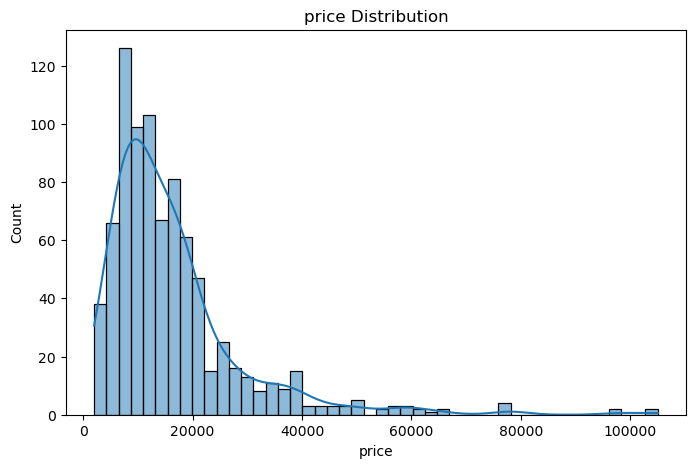

C:\Users\Rithish\.anaconda\kkk\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


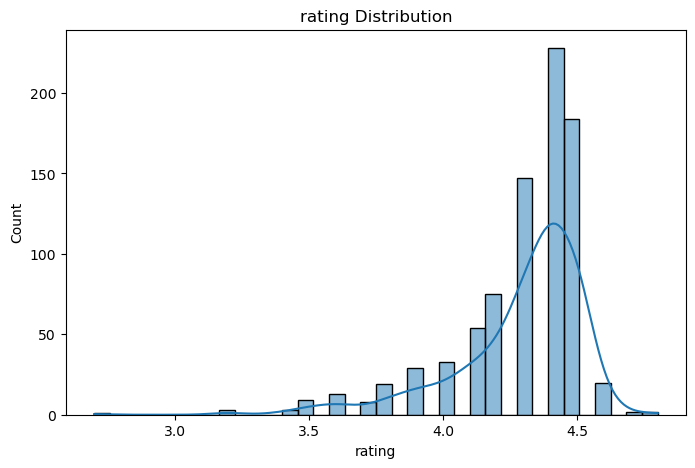

C:\Users\Rithish\.anaconda\kkk\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


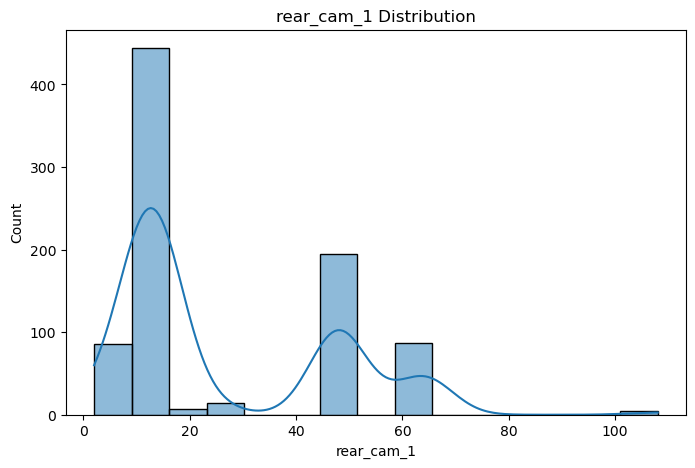

C:\Users\Rithish\.anaconda\kkk\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


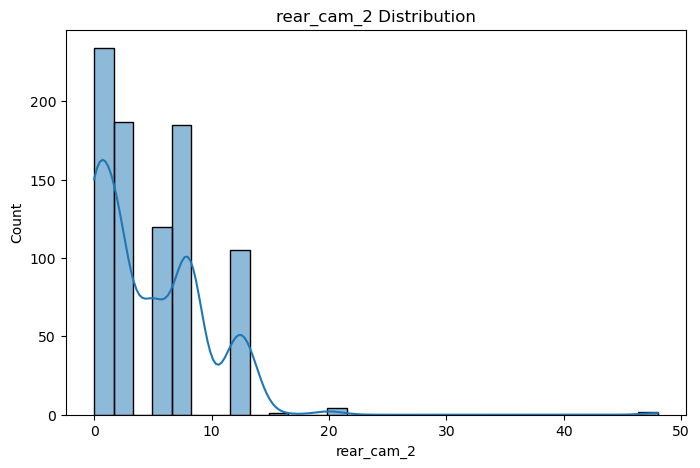

C:\Users\Rithish\.anaconda\kkk\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


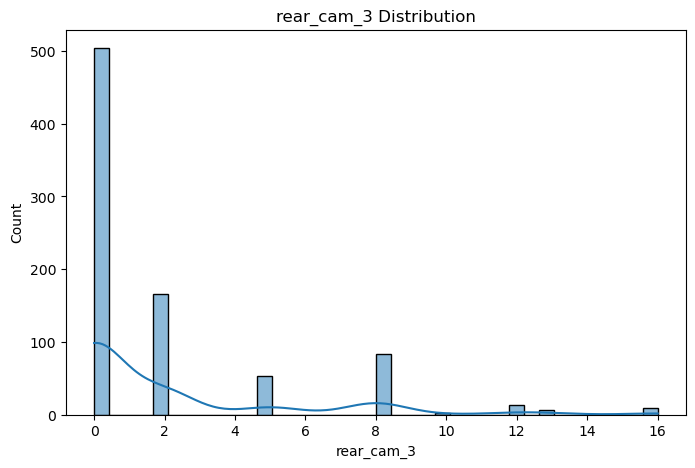

C:\Users\Rithish\.anaconda\kkk\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


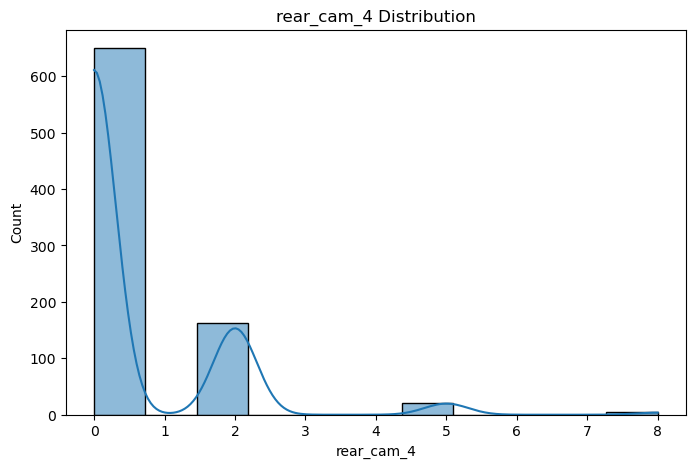

C:\Users\Rithish\.anaconda\kkk\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


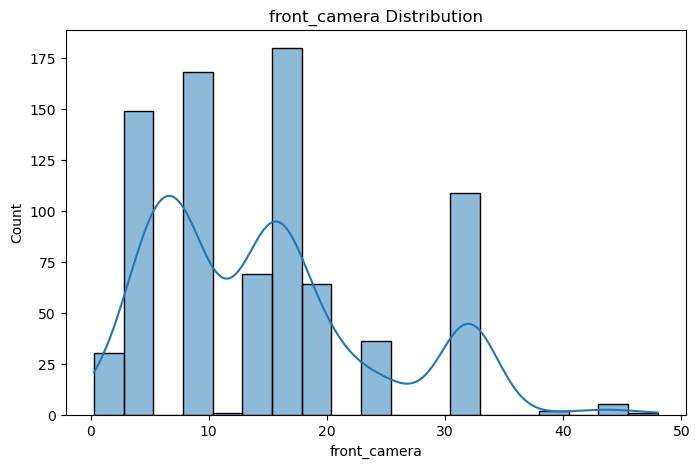

C:\Users\Rithish\.anaconda\kkk\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


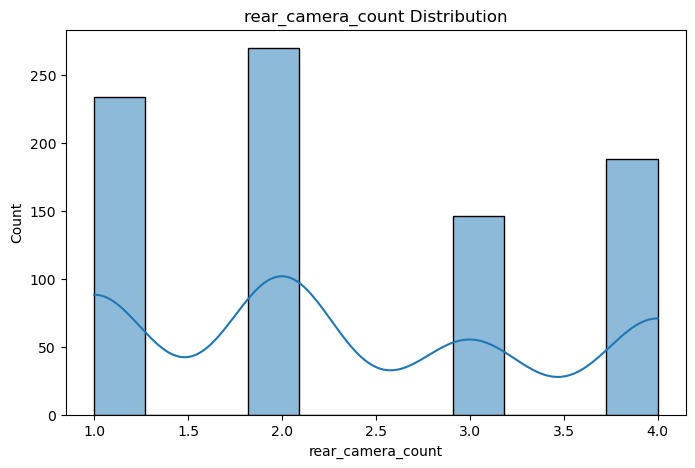

C:\Users\Rithish\.anaconda\kkk\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


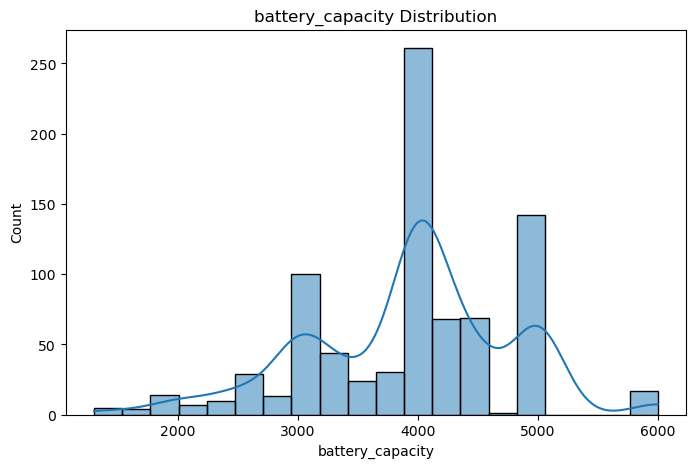

C:\Users\Rithish\.anaconda\kkk\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


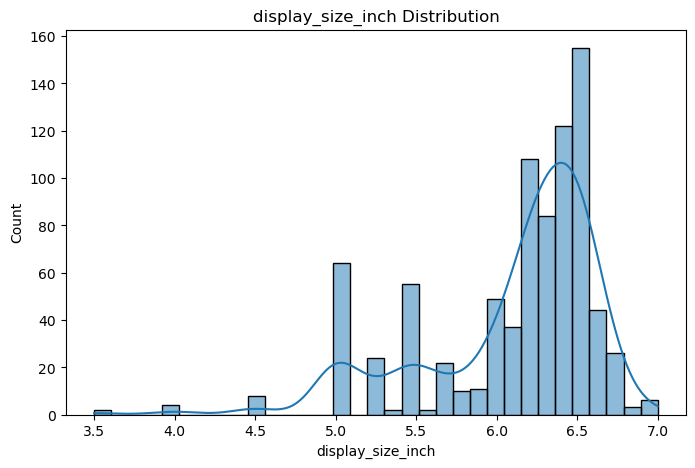

C:\Users\Rithish\.anaconda\kkk\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


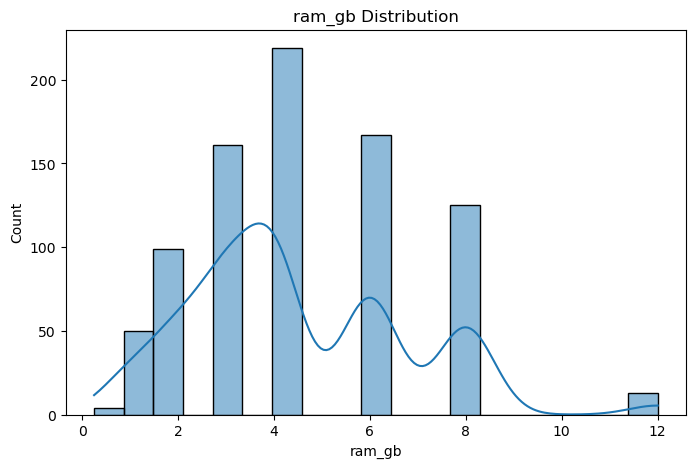

C:\Users\Rithish\.anaconda\kkk\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


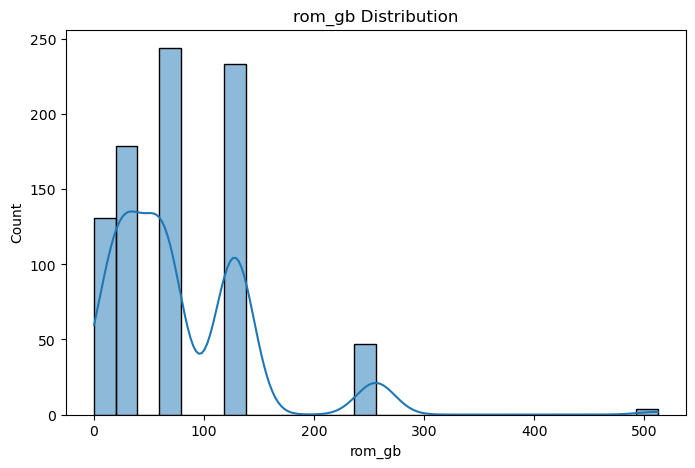

C:\Users\Rithish\.anaconda\kkk\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


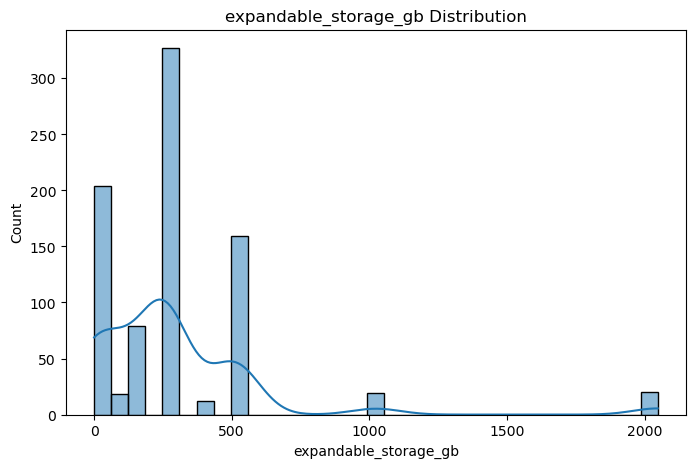

C:\Users\Rithish\.anaconda\kkk\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


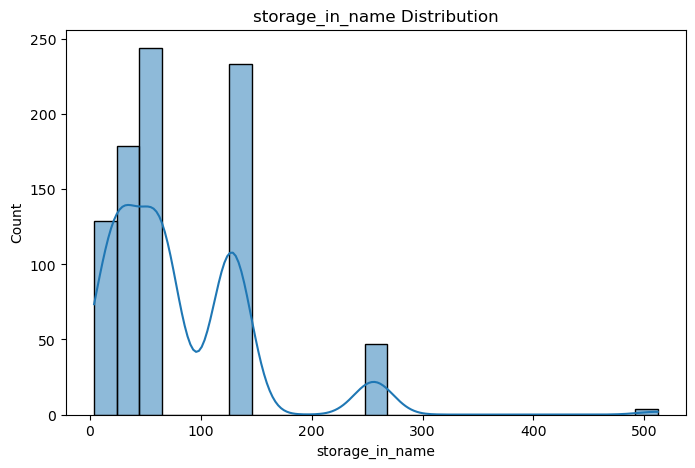

C:\Users\Rithish\.anaconda\kkk\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


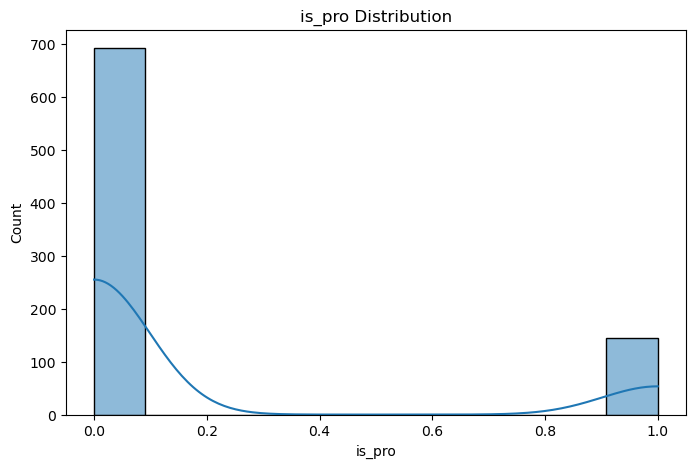

C:\Users\Rithish\.anaconda\kkk\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


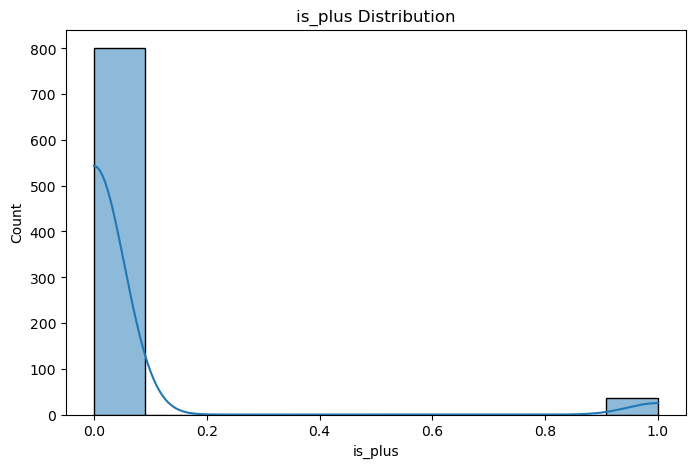

C:\Users\Rithish\.anaconda\kkk\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


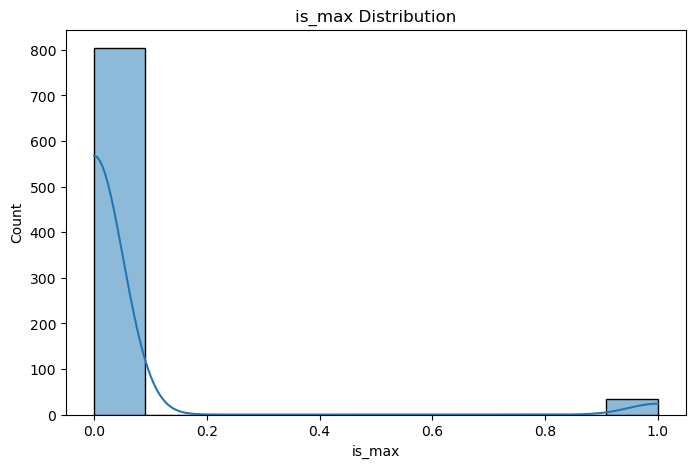

C:\Users\Rithish\.anaconda\kkk\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


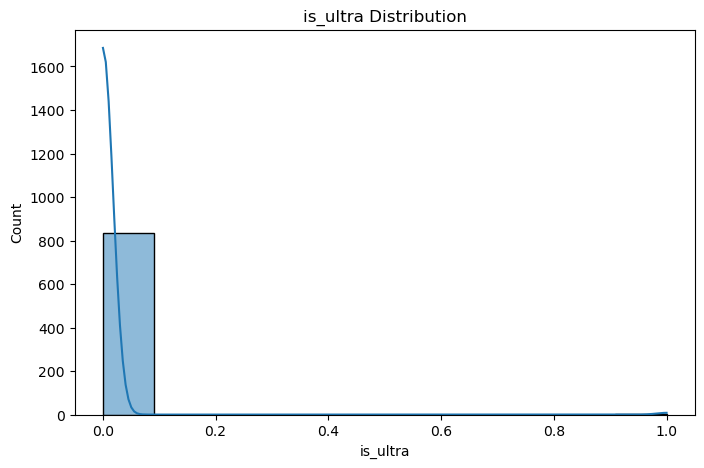

C:\Users\Rithish\.anaconda\kkk\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


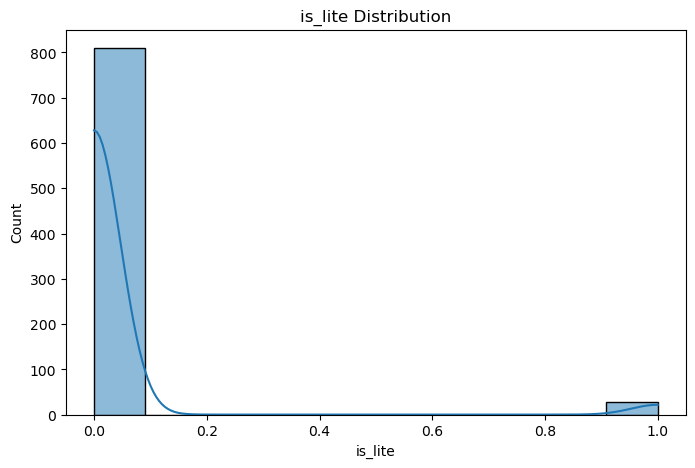

C:\Users\Rithish\.anaconda\kkk\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


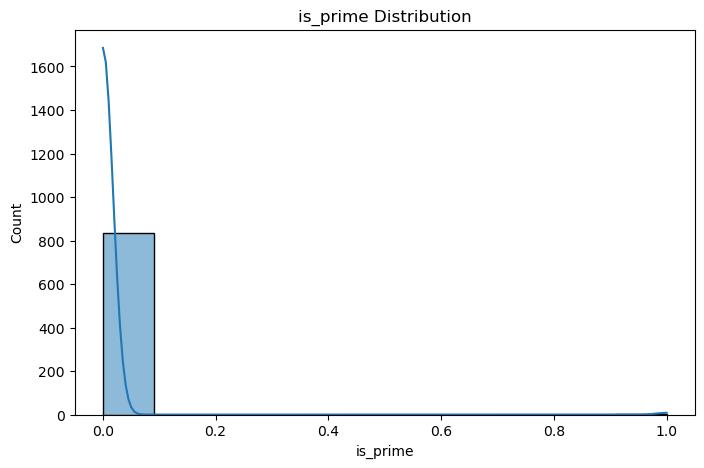

C:\Users\Rithish\.anaconda\kkk\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


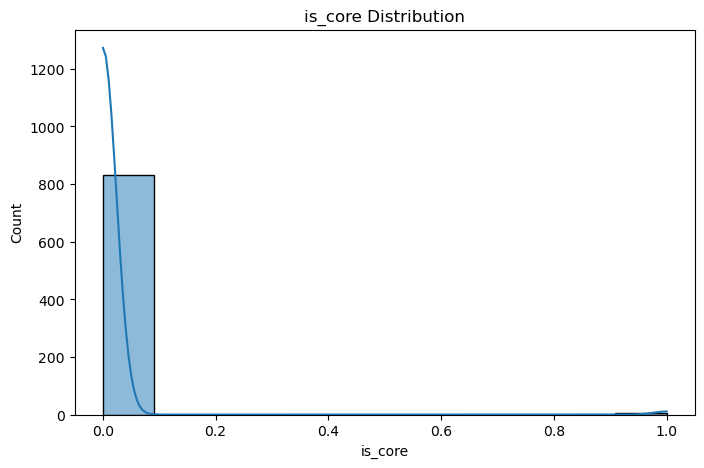

C:\Users\Rithish\.anaconda\kkk\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


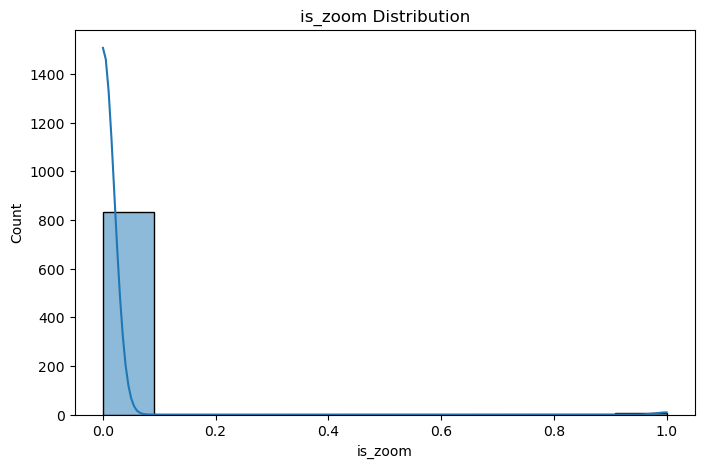

C:\Users\Rithish\.anaconda\kkk\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


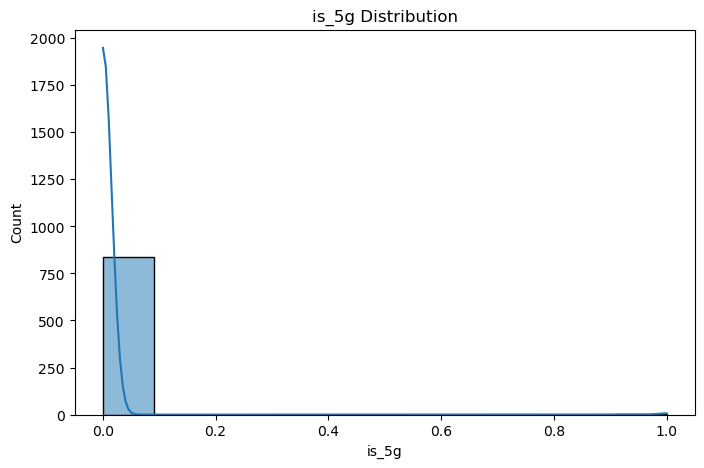

C:\Users\Rithish\.anaconda\kkk\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


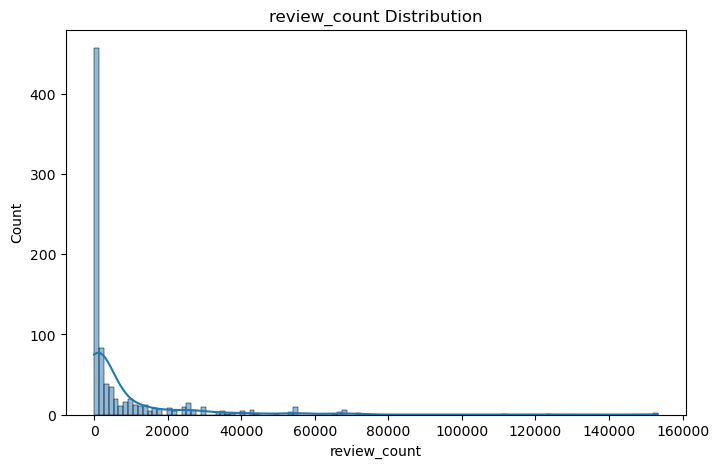

In [53]:
save_path = r"C:\Users\Rithish\Desktop\graph"

os.makedirs(save_path, exist_ok=True)

# ------------------------------------------
# LOOP
# ------------------------------------------

for col in num_cols:

    # create figure
    plt.figure(figsize=(8,5))

    # plot
    sns.histplot(df[col], kde=True)

    plt.title(f"{col} Distribution")

    # --------------------------------------
    # SAVE BEFORE SHOW
    # --------------------------------------

    plt.savefig(
        rf"{save_path}\{col}.png",
        dpi=300,
        bbox_inches="tight"
    )

    # now show
    plt.show()

    # close
    plt.close()

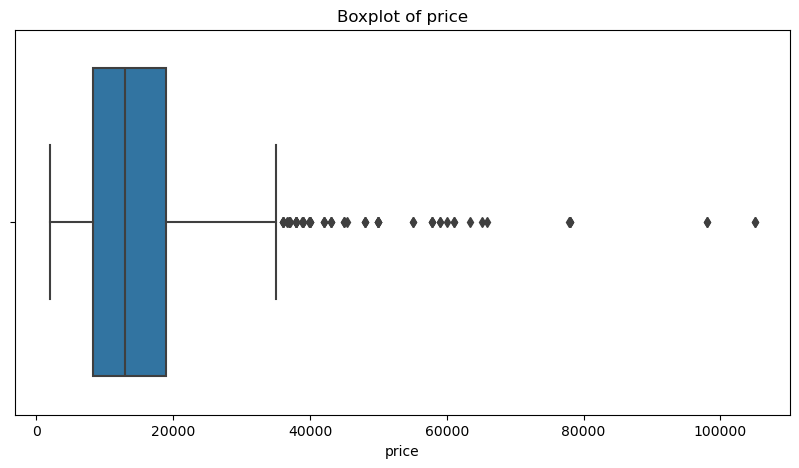

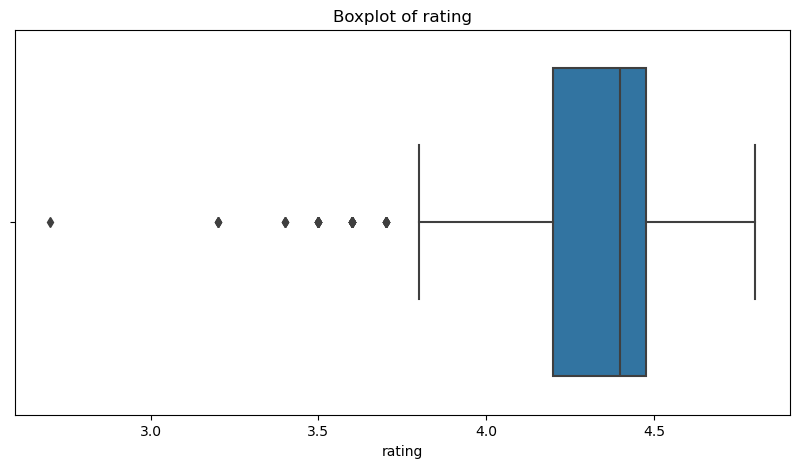

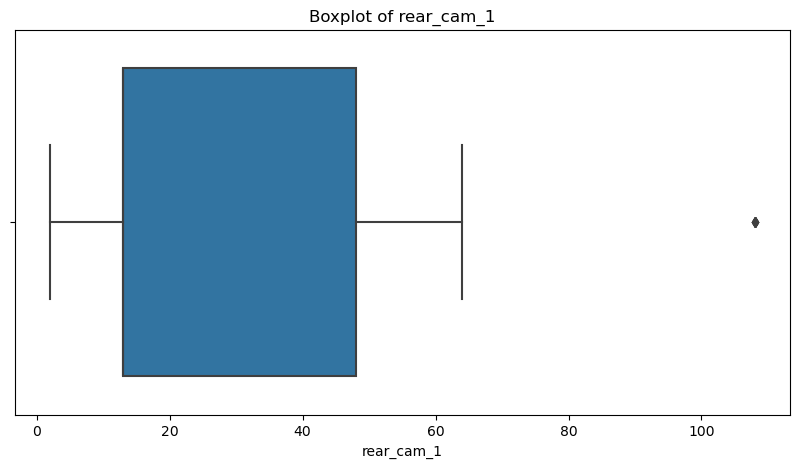

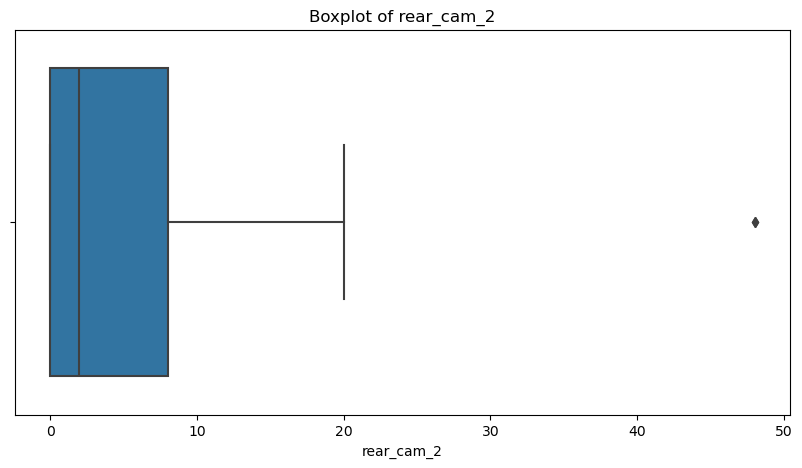

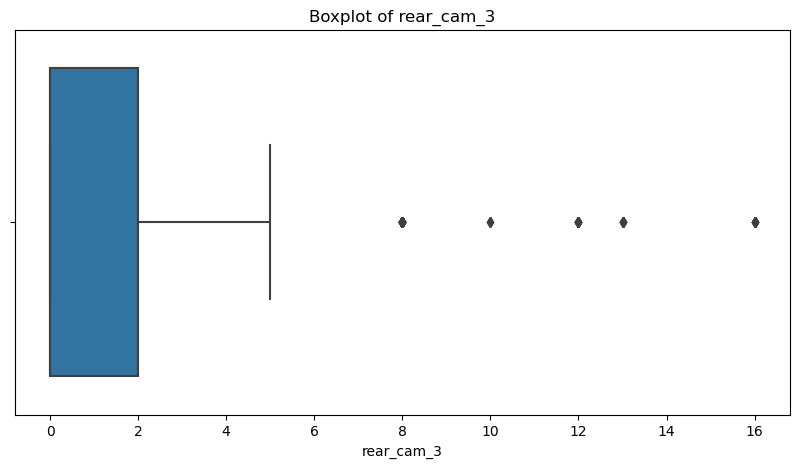

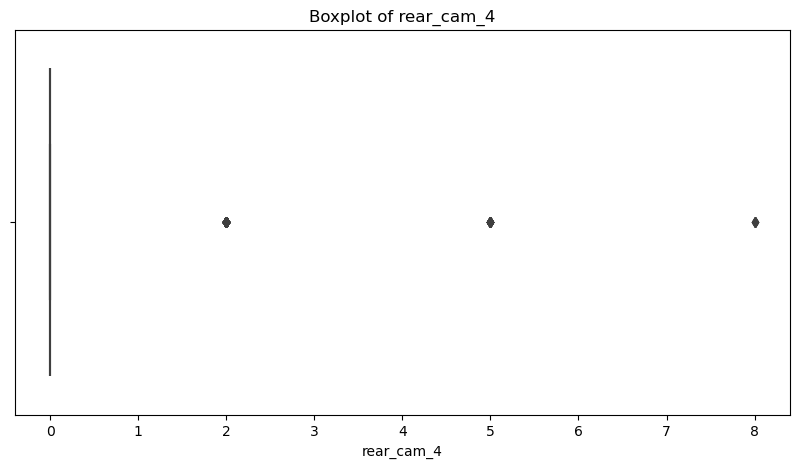

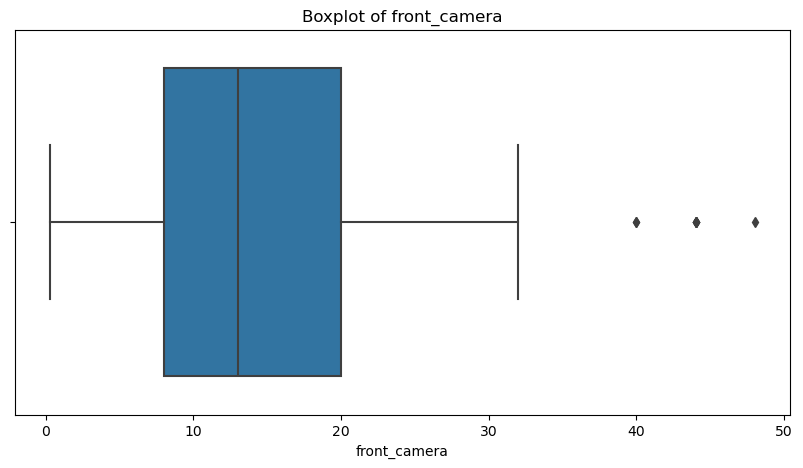

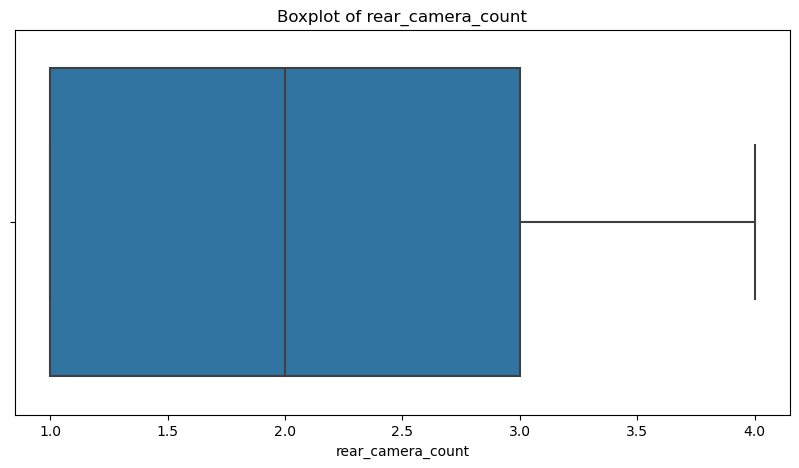

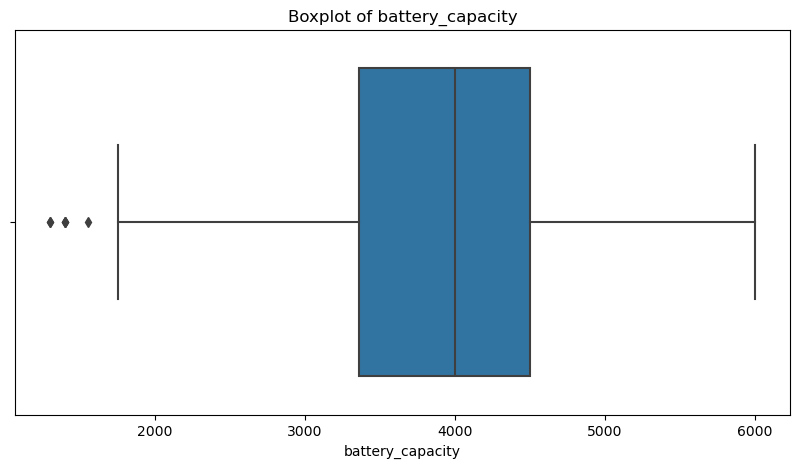

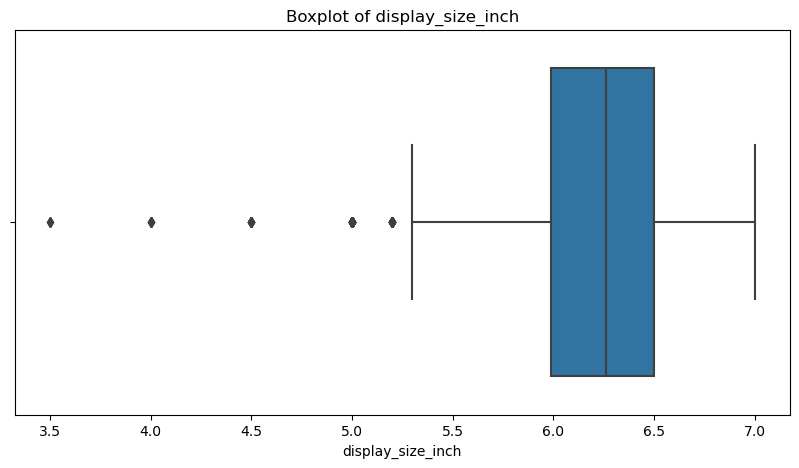

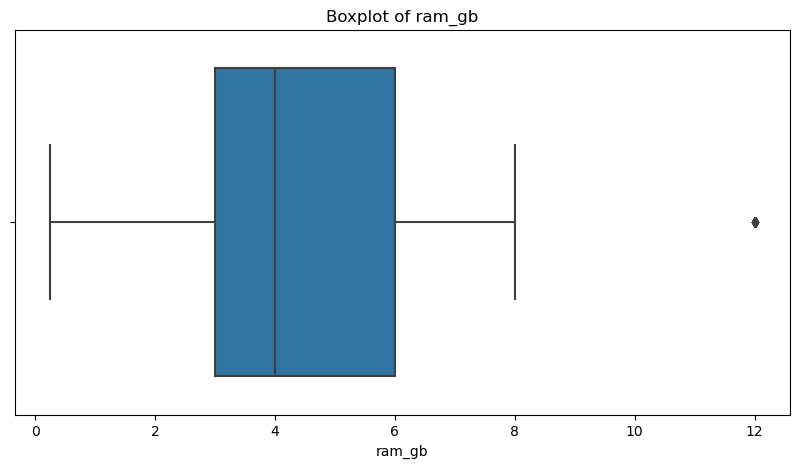

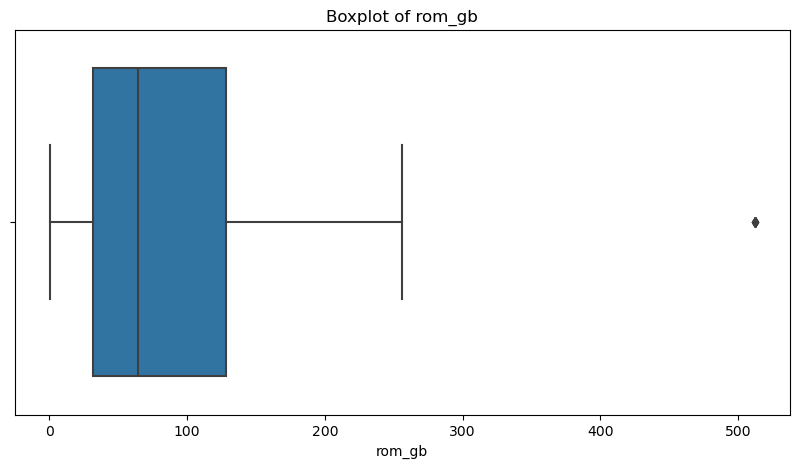

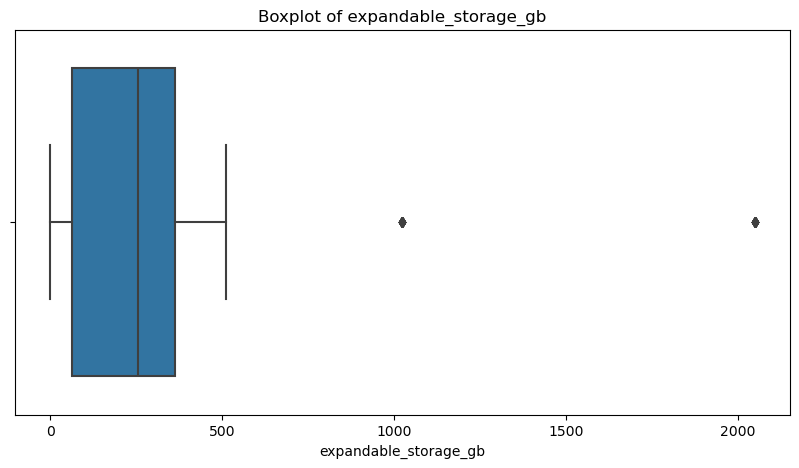

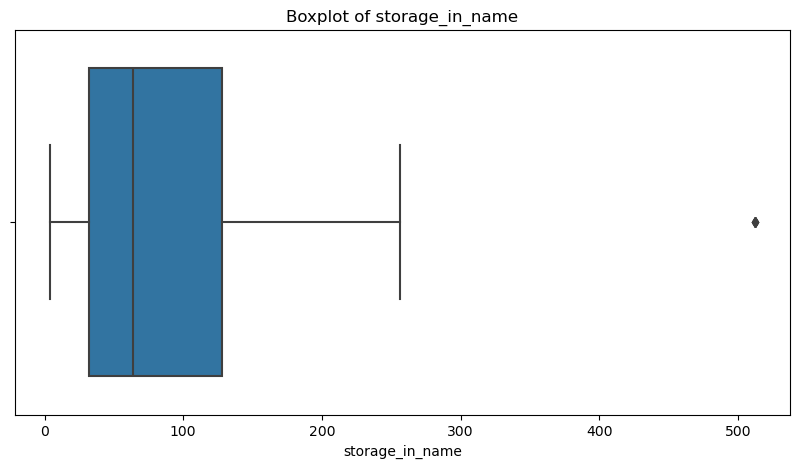

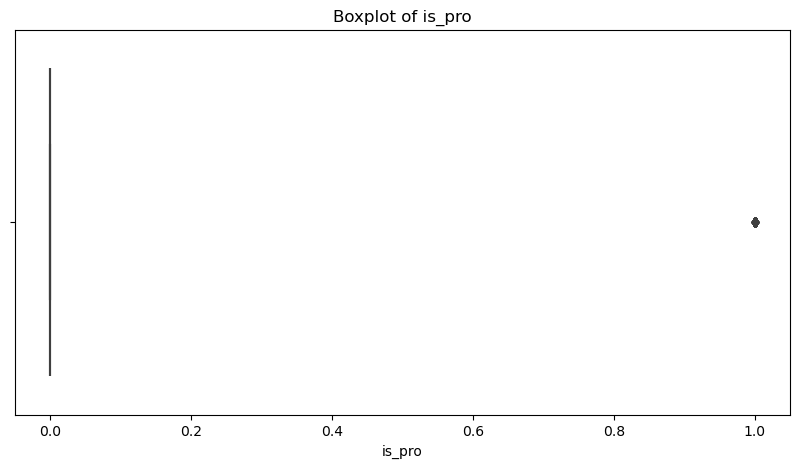

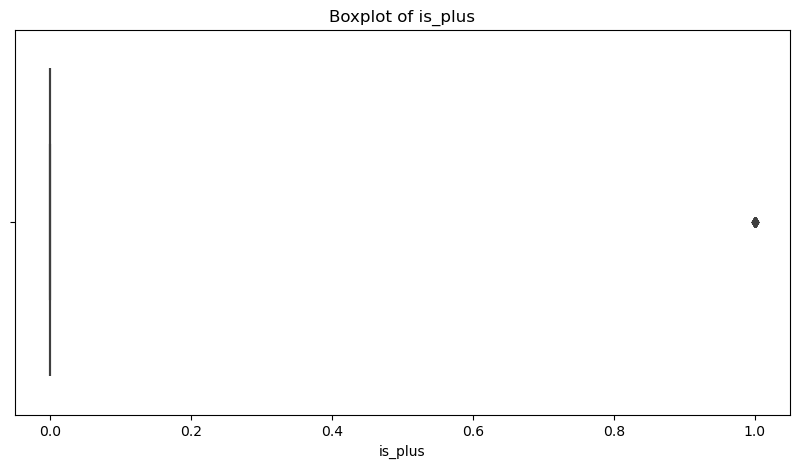

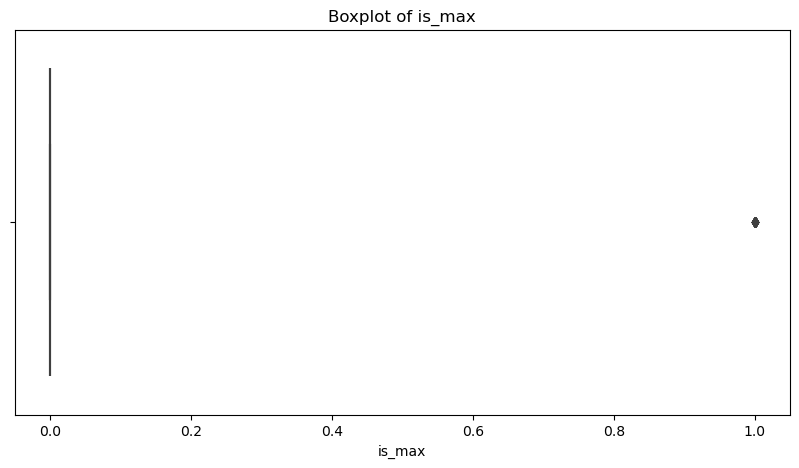

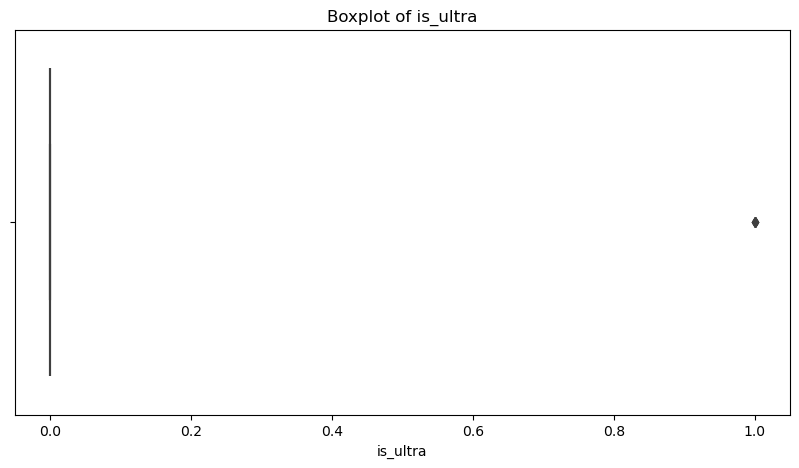

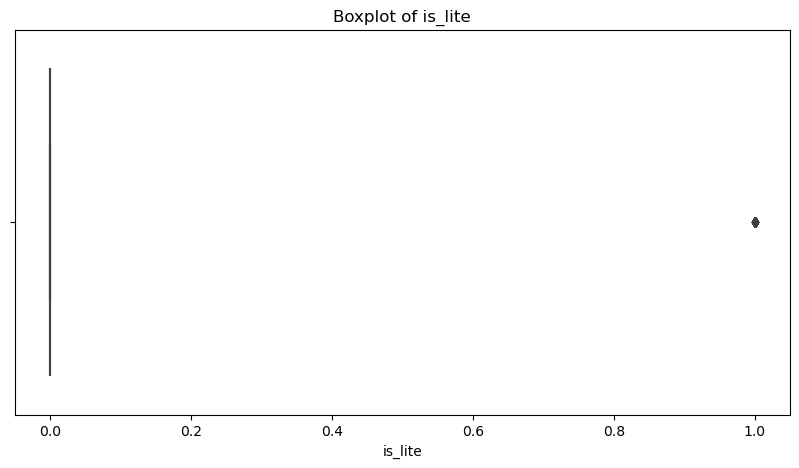

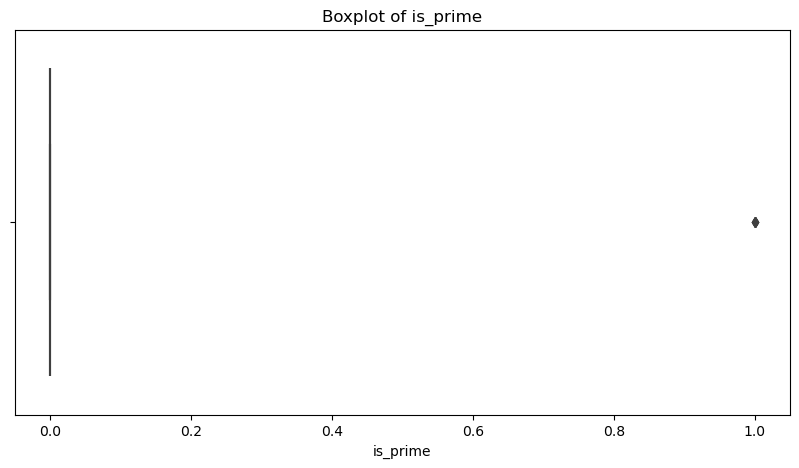

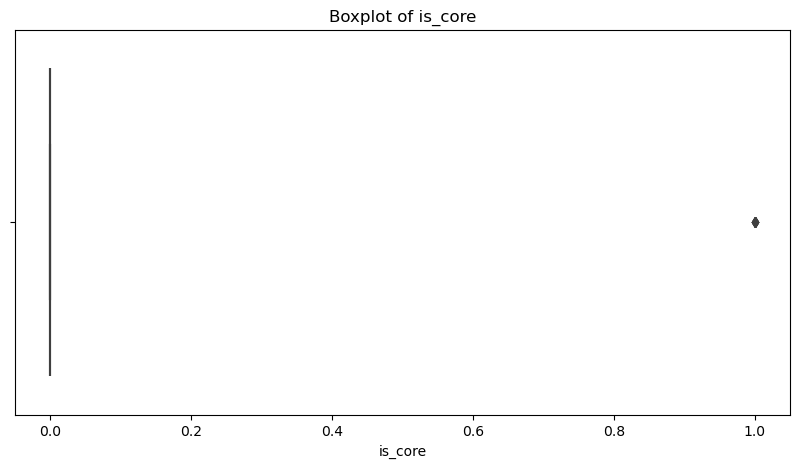

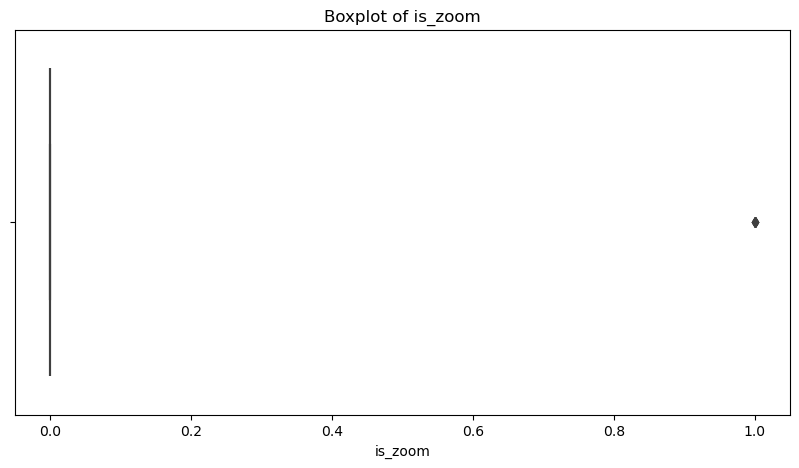

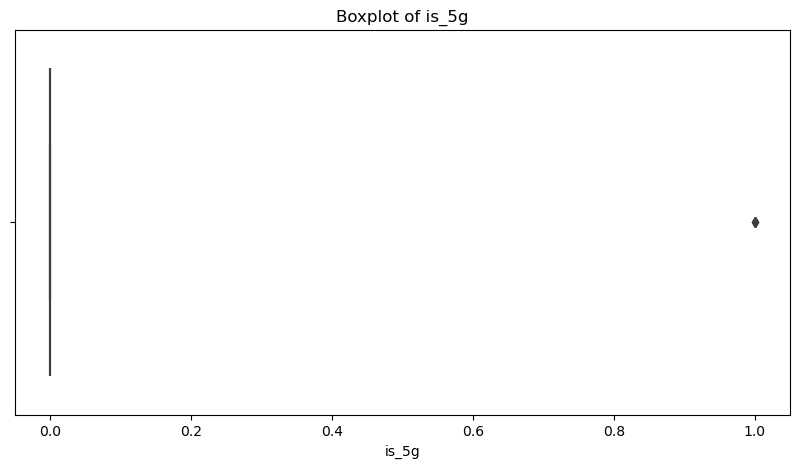

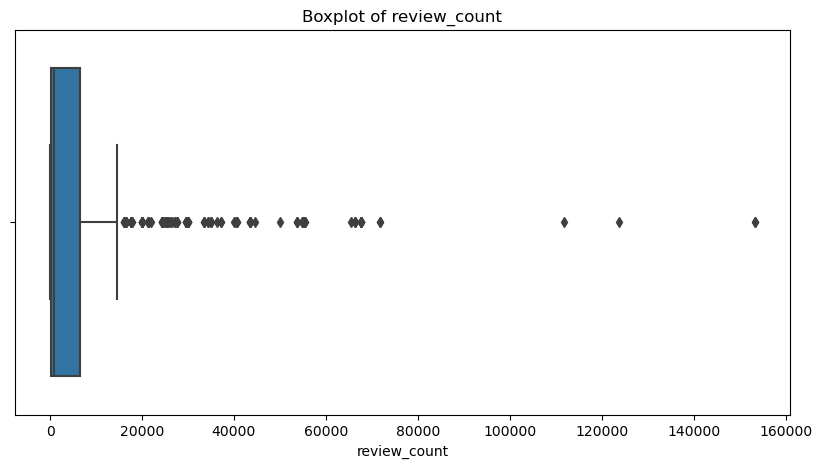

In [54]:
save_path = r"C:\Users\Rithish\Desktop\graph"
for col in num_cols:

    # create figure
    plt.figure(figsize=(10,5))

    # boxplot
    sns.boxplot(x=df[col])

    # title
    plt.title(f"Boxplot of {col}")

    # --------------------------------------
    # SAVE GRAPH
    # --------------------------------------

    plt.savefig(
        rf"{save_path}\{col}.png",
        dpi=300,
        bbox_inches="tight"
    )

    # show
    plt.show()

    # close
    plt.close()

In [55]:
def skew_spread(data):
    for i in data:
        print('*'*20, i, '*'*20)
        print(f"skewness of {i} ",data[i].skew())
        print(f"std of {i} ",data[i].std())
        print()

skew_spread(num_cols)

******************** price ********************
skewness of price  2.806972349384207
std of price  12965.135410691417

******************** rating ********************
skewness of rating  -1.7520457897978494
std of rating  0.24809193815614988

******************** rear_cam_1 ********************
skewness of rear_cam_1  0.9703273520537854
std of rear_cam_1  20.734169991924333

******************** rear_cam_2 ********************
skewness of rear_cam_2  2.151141906807741
std of rear_cam_2  4.853349604235419

******************** rear_cam_3 ********************
skewness of rear_cam_3  1.967972298389585
std of rear_cam_3  3.3838390674816106

******************** rear_cam_4 ********************
skewness of rear_cam_4  2.789075892971413
std of rear_cam_4  1.1859339576115686

******************** front_camera ********************
skewness of front_camera  0.8229545635423106
std of front_camera  9.395288400637265

******************** rear_camera_count ********************
skewness of rear_cam

### price

**Distribution**
Highly Right Skewed

Observation

Price ranges from ₹1,999 to ₹1,04,999.
Mean price (~₹16.3K) is greater than median (~₹12.9K).
Most phones are concentrated in lower price ranges.
Few expensive phones create many outliers.

Business Insight

Dataset mainly contains budget and mid-range smartphones.
Premium flagship phones are fewer in number.
Expensive phones increase the overall average price.

### rating

**Distribution**
Left Skewed

Observation

Ratings are mostly concentrated between 4.0 and 4.5.
Mean and median are very close.
Very low-rated phones are limited.

Business Insight

Most smartphones in the dataset receive good customer feedback.
Customers generally show positive satisfaction toward smartphones.

### battery_capacity

**Distribution**
Slight Left Skew / Near Normal

Observation

Battery capacity ranges from 1300mAh to 6000mAh.
Most phones are concentrated around 4000–5000mAh.
Very low battery phones appear as outliers.

Business Insight

Large battery backup has become standard in smartphones.
Modern phones mainly focus on higher battery capacity.

### display_size_inch

**Distribution**
Left Skewed

Observation

Display sizes mainly range between 6 and 6.5 inches.
Smaller display phones are fewer.
Large-screen devices dominate the dataset.

Business Insight

Customers prefer larger screen smartphones.
Compact smartphones are less common in the dataset.

### ram_gb

**Distribution**
Right Skewed

Observation

4GB RAM phones are most common.
Higher RAM phones appear less frequently.
Few premium phones create outliers.

Business Insight

Mid-range RAM configurations dominate the market.
Premium high-performance phones are comparatively fewer.

### rom_gb

**Distribution**
Highly Right Skewed

Observation

64GB storage appears most frequently.
Very high storage variants are fewer.
Storage values spread widely across the dataset.

Business Insight

Standard storage variants dominate smartphone sales.
Ultra-high storage models belong mainly to premium categories.

### front_camera

**Distribution**
Right Skewed

Observation

Most front cameras lie between 8MP and 16MP.
Very high selfie cameras are uncommon.
Few premium selfie phones create outliers.

Business Insight

Moderate selfie camera quality dominates the dataset.
Premium selfie-focused devices are limited.


### eview_count

**Distribution**
Extremely Right Skewed

Observation

Most phones have lower review counts.
Few phones contain extremely high reviews.
Large outliers are visible in the dataset.

Business Insight

Only few devices dominate customer popularity and sales.
Majority of phones receive moderate market attention.


------

In [56]:
def discrete_univariate_analysis(discrete_data):
    for col_name in discrete_data:
        print("\n" + "="*60)
        print(f"UNIVARIATE ANALYSIS : {col_name}")
        print("="*60)
        print(discrete_data[col_name].agg(['count', 'nunique', 'unique']))
        print('Value Counts: \n', discrete_data[col_name].value_counts())
        print(f"\nMost Frequent Value : { discrete_data[col_name].mode()[0]}")
        print("\nPercentage Distribution:\n")
        print(round(df[col].value_counts(normalize=True) * 100,2))
        print()

In [57]:
discrete_univariate_analysis(cat_col)


UNIVARIATE ANALYSIS : processor_brand
count                                                    838
nunique                                                    7
unique     [snapdragon, mediatek, other, exynos, kirin, u...
Name: processor_brand, dtype: object
Value Counts: 
 processor_brand
snapdragon    409
mediatek      235
other          75
exynos         70
kirin          30
spreadtrum     14
unisoc          5
Name: count, dtype: int64

Most Frequent Value : snapdragon

Percentage Distribution:

review_count
0.0        1.43
10091.0    0.95
20062.0    0.95
55078.0    0.84
1.0        0.84
           ... 
1028.0     0.12
39973.0    0.12
972.0      0.12
126.0      0.12
81.0       0.12
Name: proportion, Length: 354, dtype: float64


UNIVARIATE ANALYSIS : processor_series
count                                                    838
nunique                                                   25
unique     [400, 600, p22, g70, g90, 700, unknown, p70, 8...
Name: processor_series, dtype: object

In [58]:
cat_col

,processor_brand,processor_series,processor_type,core_type,camera_type,resolution_type,brand,color,model_name
0,snapdragon,400,normal,unknown,dual,hd_plus,Redmi,Ruby Red,Redmi 8
1,snapdragon,600,normal,unknown,quad,hd_plus,Realme,Aqua Blue,Realme 5i
2,snapdragon,600,normal,unknown,quad,hd_plus,Realme,Aqua Blue,Realme 5i
3,snapdragon,600,normal,unknown,quad,hd_plus,Realme,Forest Green,Realme 5i
4,mediatek,p22,normal,octa,dual,hd_plus,Realme,Diamond Blue,Realme C2
...,...,...,...,...,...,...,...,...,...
978,other,unknown,normal,quad,single,hd,Gionee,Gold,Gionee P5L
980,snapdragon,800,normal,unknown,single,full_hd,Nextbit,Ember,Nextbit Robin
981,mediatek,p25,normal,unknown,dual,full_hd,Gionee,Mocha Gold,Gionee A1 Plus
982,mediatek,unknown,normal,unknown,single,hd,XOLO,Black,XOLO Omega 5.0



VISUAL ANALYSIS : processor_brand


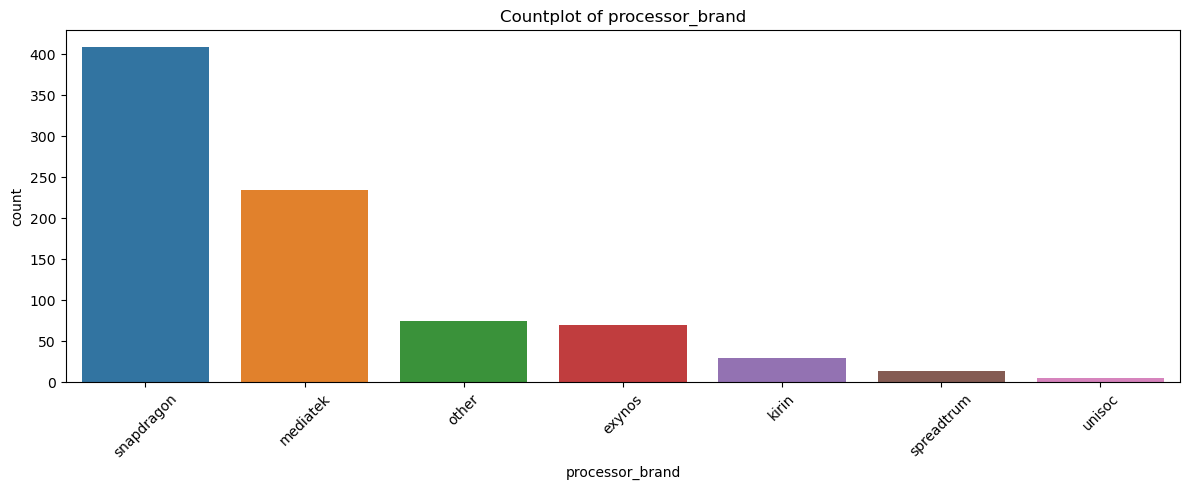


VISUAL ANALYSIS : processor_series


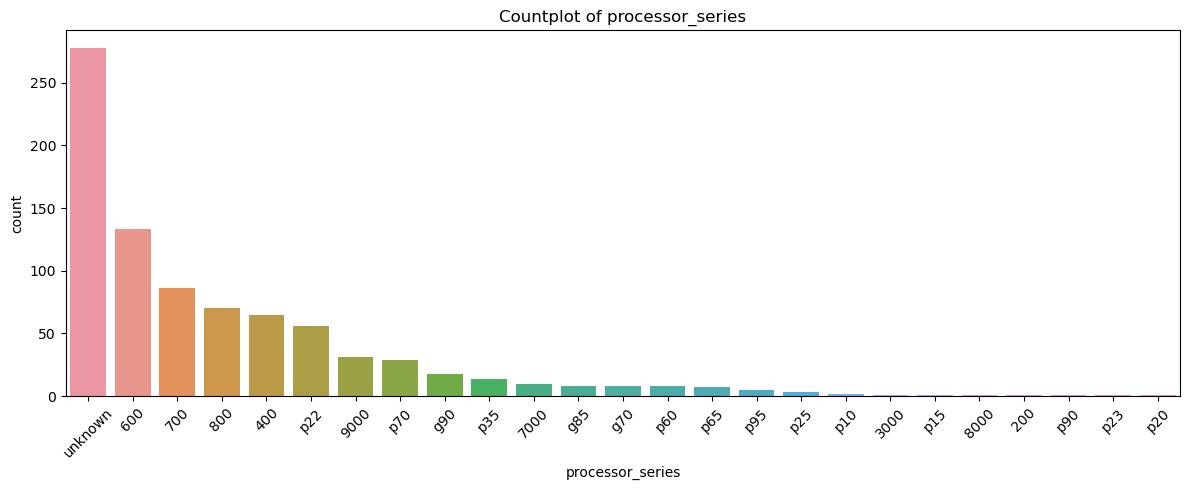


VISUAL ANALYSIS : processor_type


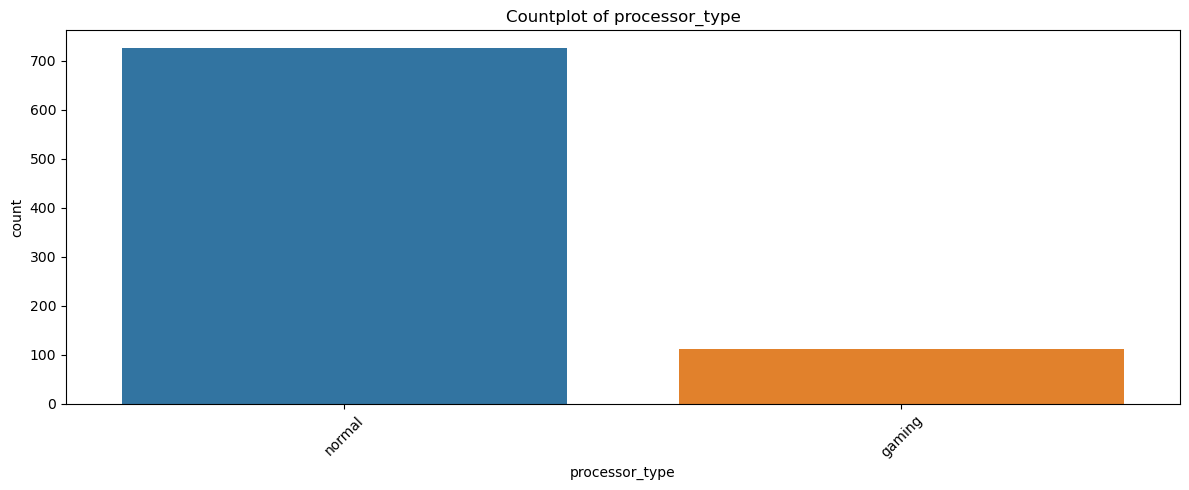


VISUAL ANALYSIS : core_type


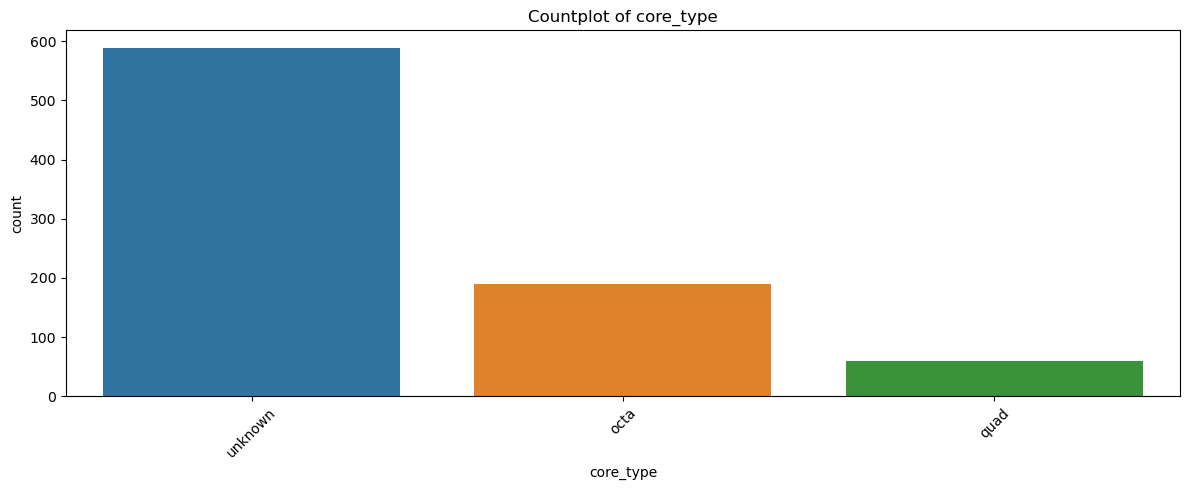


VISUAL ANALYSIS : camera_type


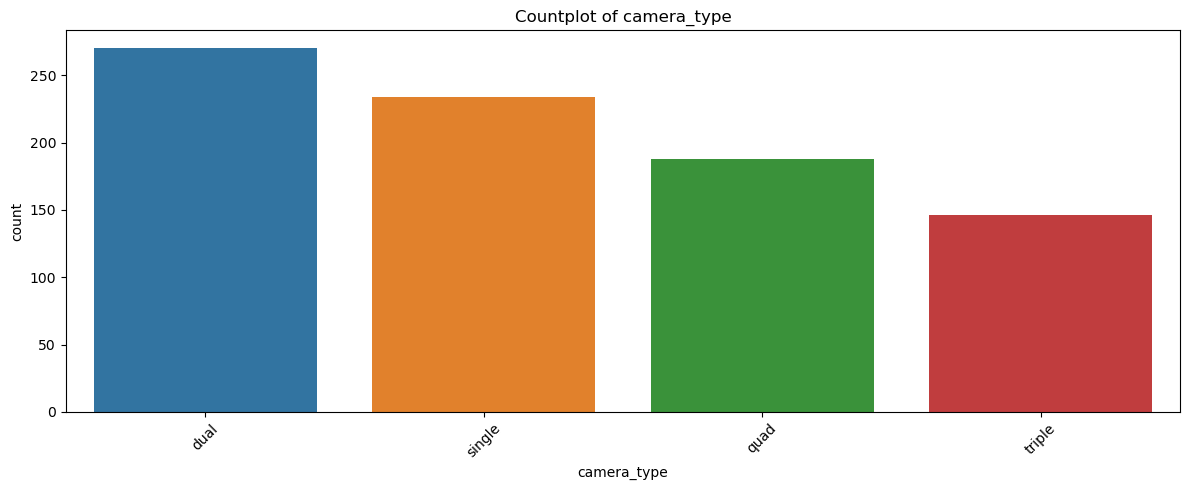


VISUAL ANALYSIS : resolution_type


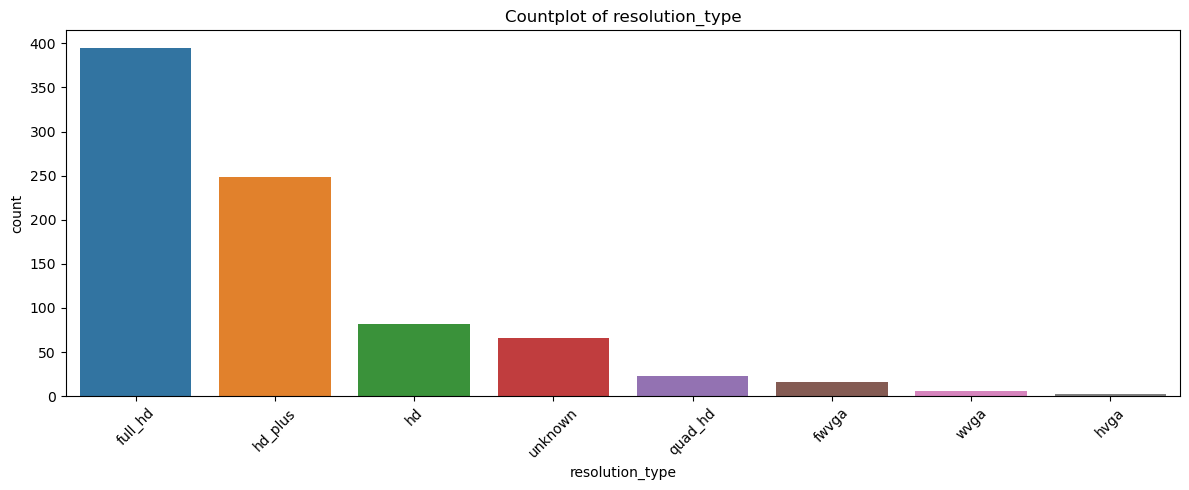


VISUAL ANALYSIS : brand


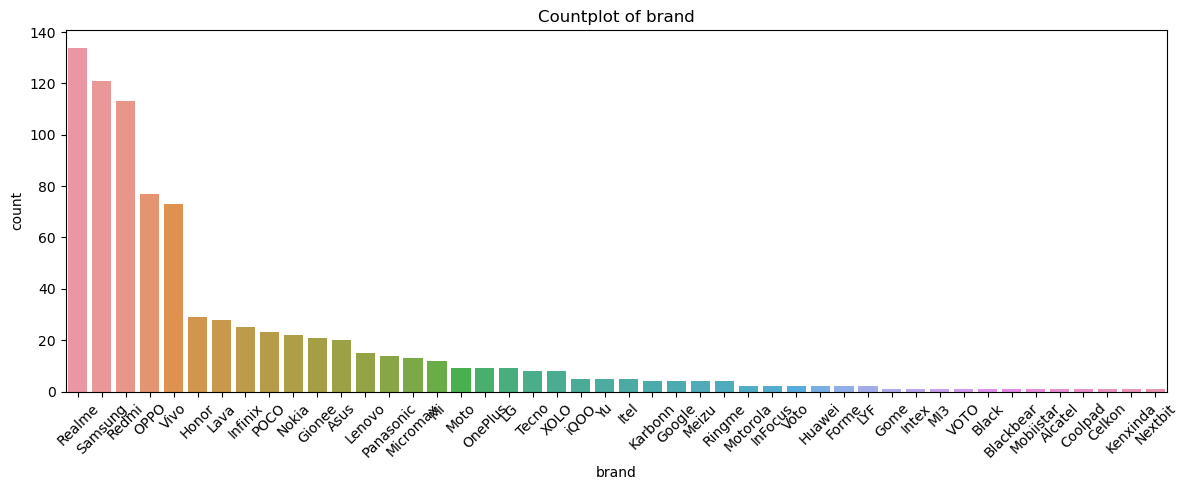


VISUAL ANALYSIS : color


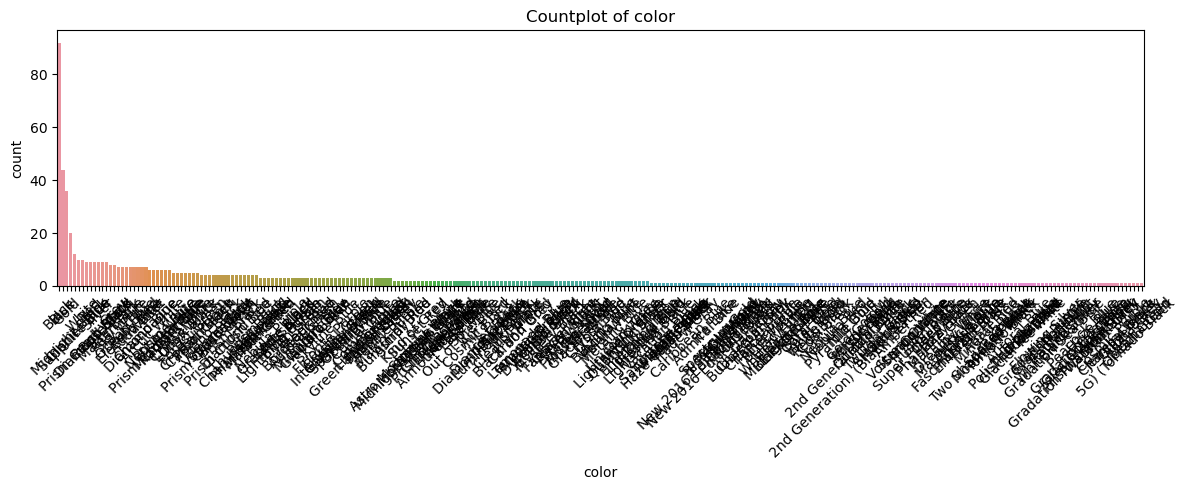


VISUAL ANALYSIS : model_name


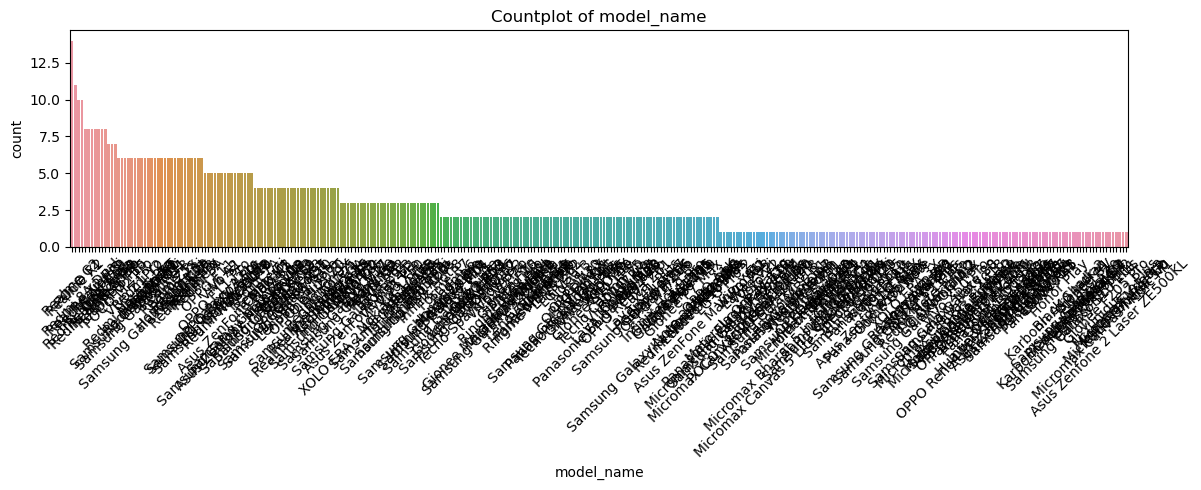

In [59]:
save_path=rf"C:\Users\Rithish\Desktop\cat_graphs"
for col in cat_col:

    print("\n" + "="*60)
    print(f"VISUAL ANALYSIS : {col}")
    print("="*60)
    plt.figure(figsize=(12,5))
    sns.countplot(x=df[col],order=df[col].value_counts().index)
    plt.title(f"Countplot of {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(rf"{save_path}\{col}.png",dpi=300,bbox_inches="tight")
    plt.show()
    plt.close()

In [60]:
target = df_new["price"]

### Bi_variate 


BIVARIATE ANALYSIS : price vs price

Correlation : 1.0


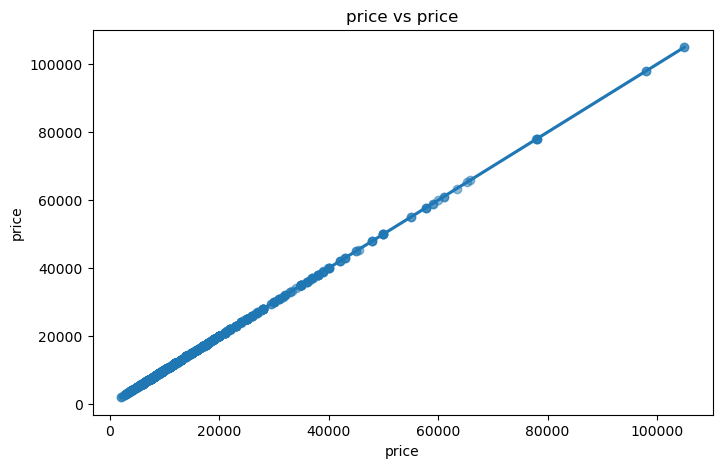


BIVARIATE ANALYSIS : rating vs price

Correlation : 0.442


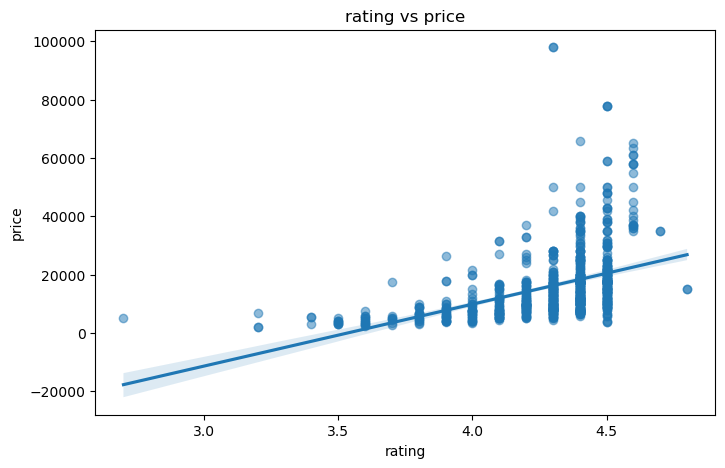


BIVARIATE ANALYSIS : rear_cam_1 vs price

Correlation : 0.549


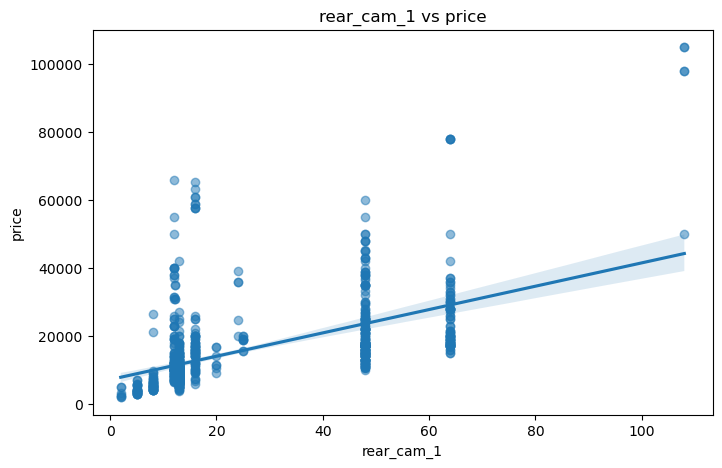


BIVARIATE ANALYSIS : rear_cam_2 vs price

Correlation : 0.683


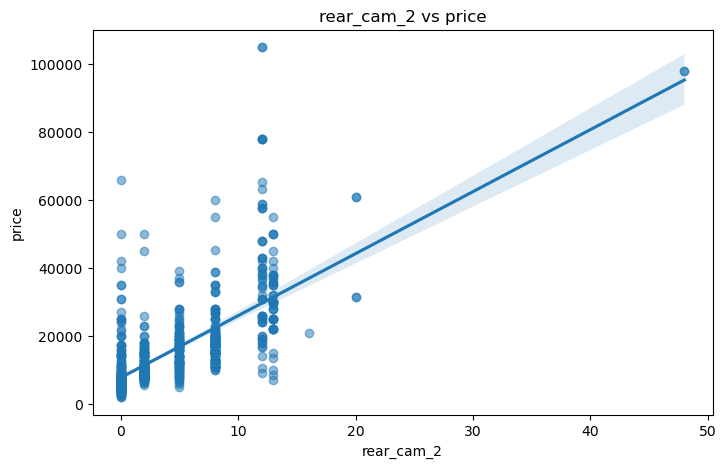


BIVARIATE ANALYSIS : rear_cam_3 vs price

Correlation : 0.579


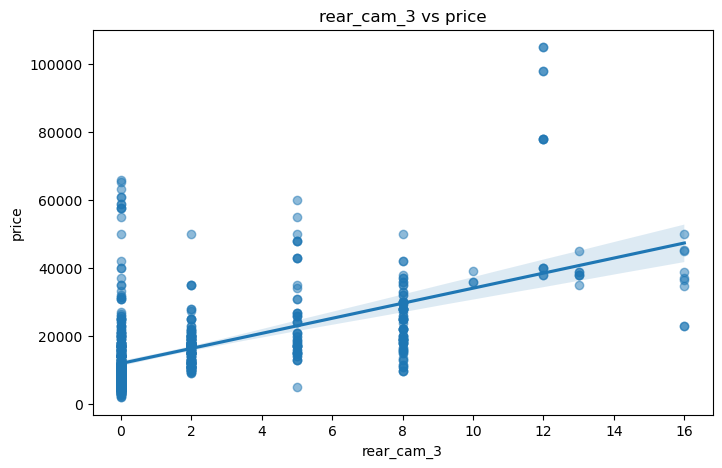


BIVARIATE ANALYSIS : rear_cam_4 vs price

Correlation : 0.242


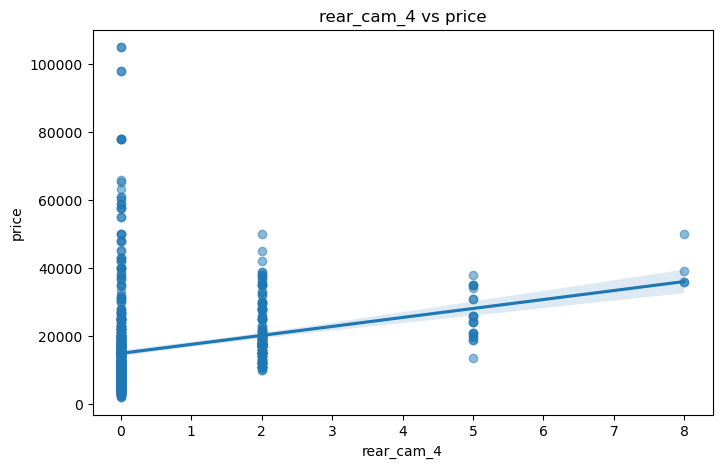


BIVARIATE ANALYSIS : front_camera vs price

Correlation : 0.442


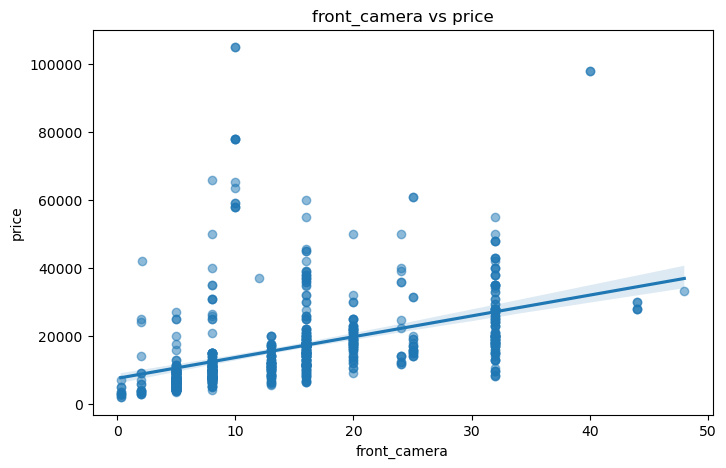


BIVARIATE ANALYSIS : rear_camera_count vs price

Correlation : 0.404


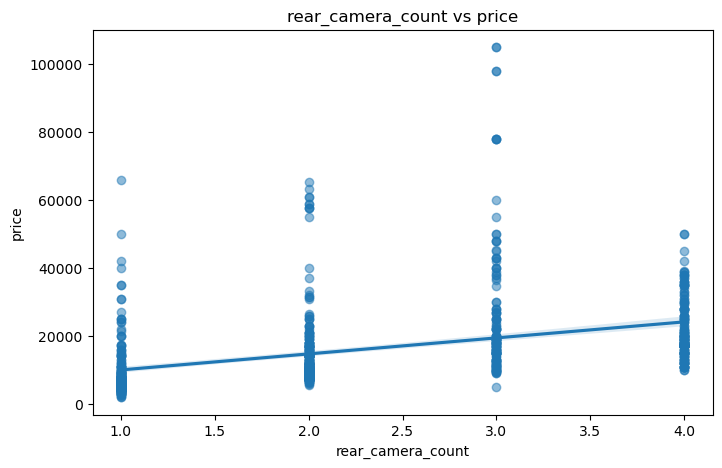


BIVARIATE ANALYSIS : battery_capacity vs price

Correlation : 0.23


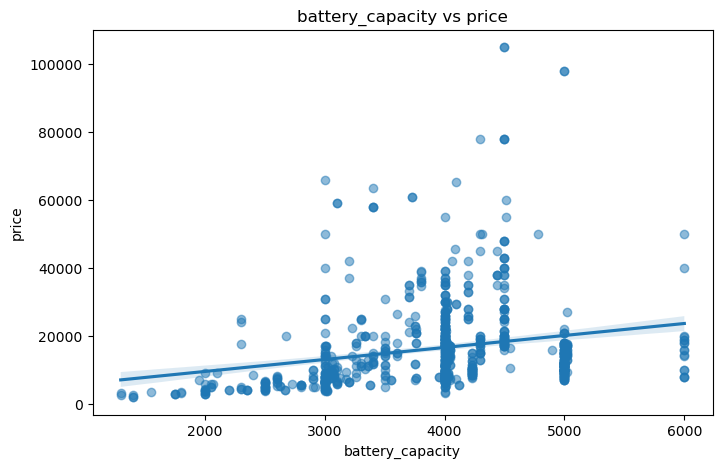


BIVARIATE ANALYSIS : display_size_inch vs price

Correlation : 0.45


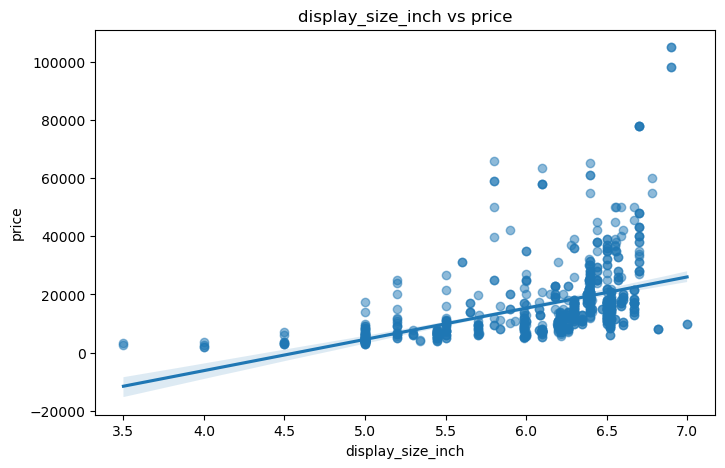


BIVARIATE ANALYSIS : ram_gb vs price

Correlation : 0.749


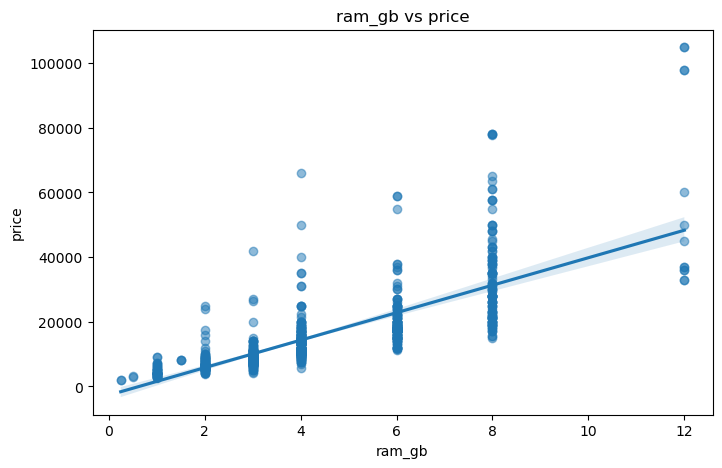


BIVARIATE ANALYSIS : rom_gb vs price

Correlation : 0.683


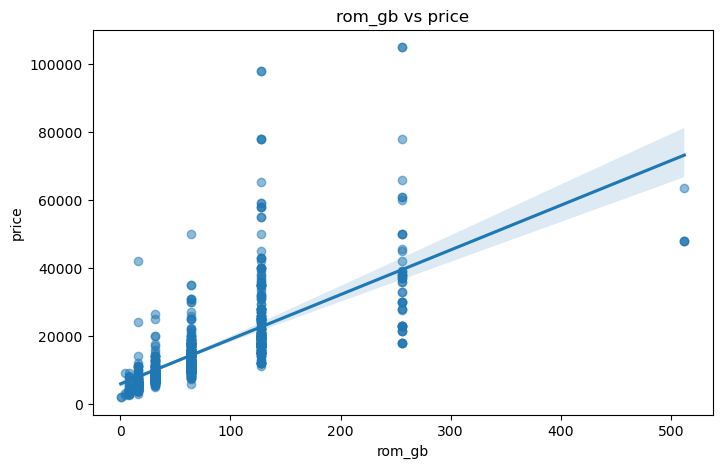


BIVARIATE ANALYSIS : expandable_storage_gb vs price

Correlation : 0.156


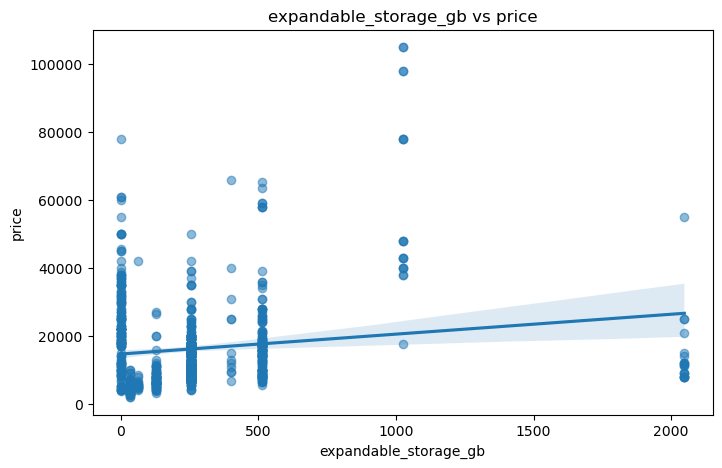


BIVARIATE ANALYSIS : storage_in_name vs price

Correlation : 0.682


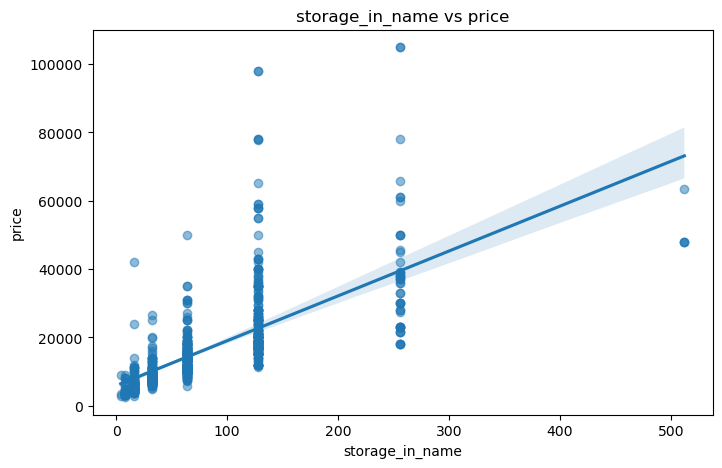


BIVARIATE ANALYSIS : is_pro vs price

Correlation : 0.088


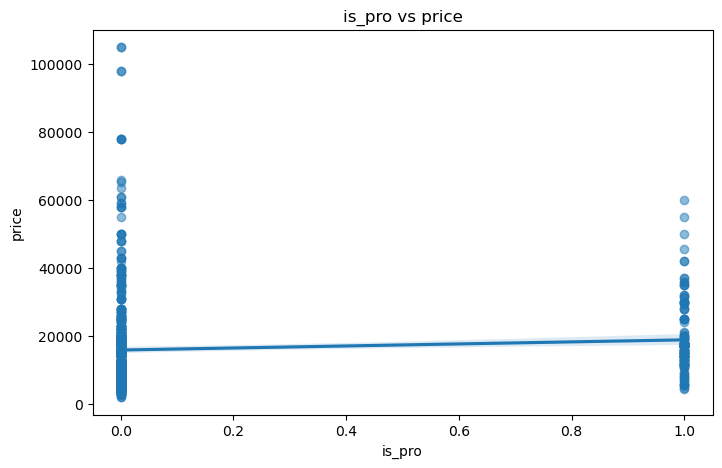


BIVARIATE ANALYSIS : is_plus vs price

Correlation : 0.065


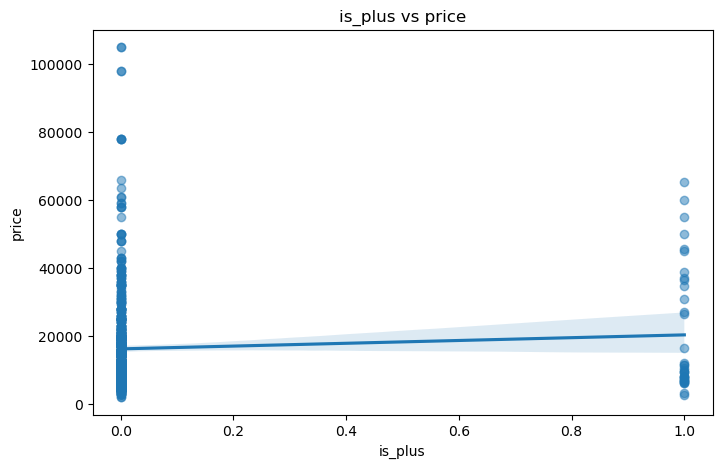


BIVARIATE ANALYSIS : is_max vs price

Correlation : -0.123


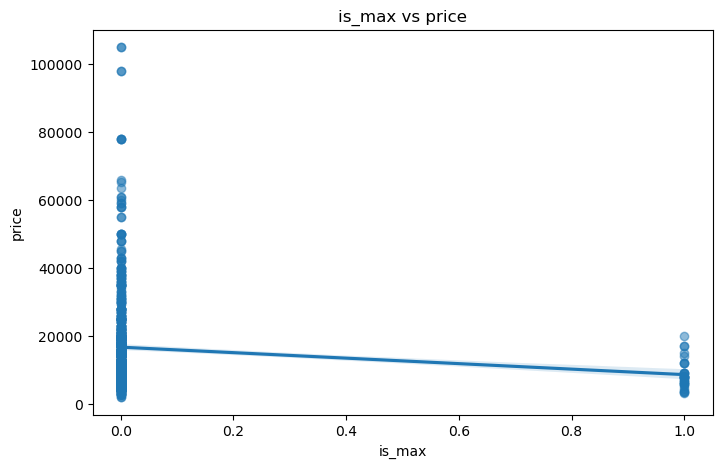


BIVARIATE ANALYSIS : is_ultra vs price

Correlation : 0.455


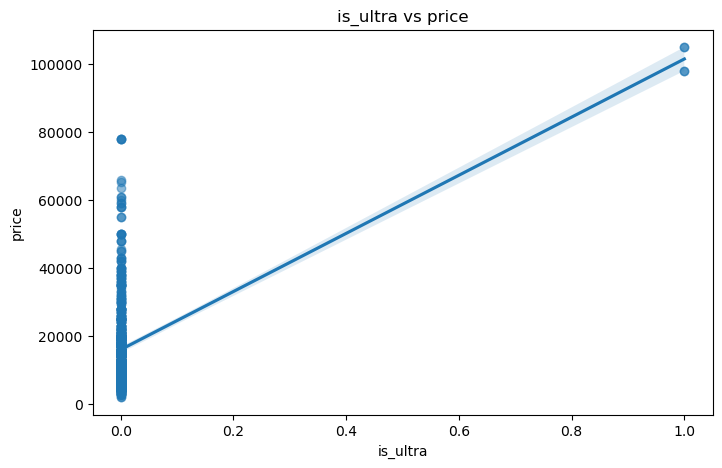


BIVARIATE ANALYSIS : is_lite vs price

Correlation : 0.114


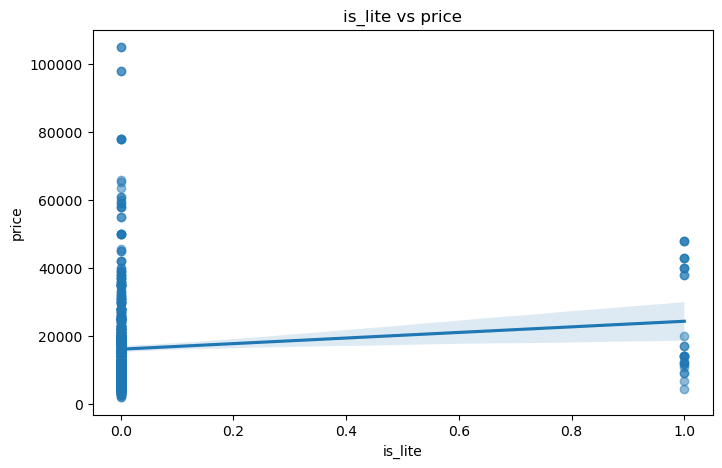


BIVARIATE ANALYSIS : is_prime vs price

Correlation : -0.019


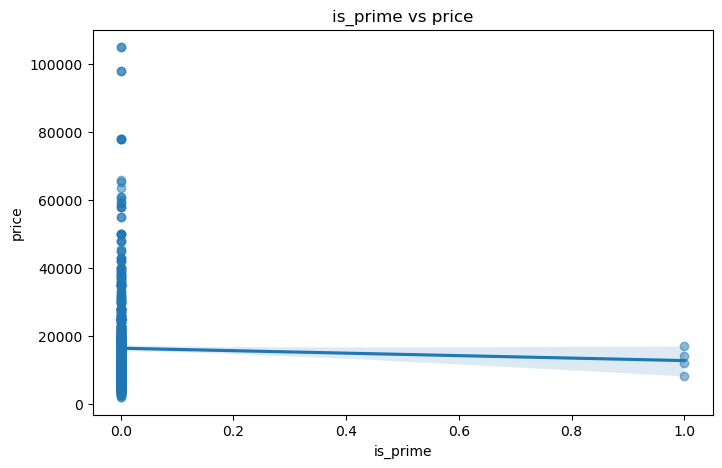


BIVARIATE ANALYSIS : is_core vs price

Correlation : -0.069


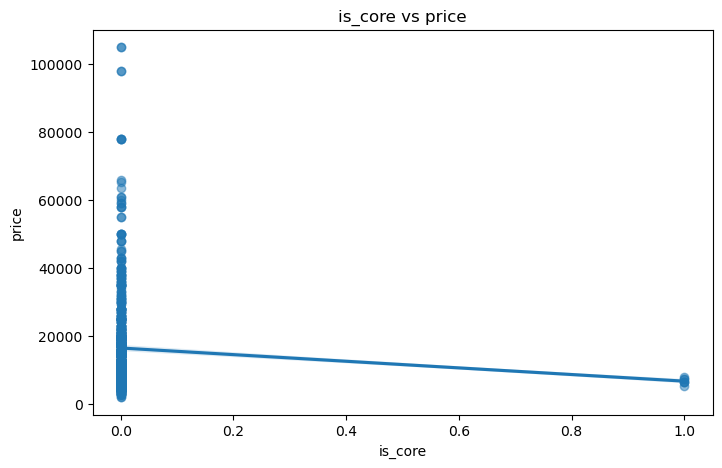


BIVARIATE ANALYSIS : is_zoom vs price

Correlation : 0.098


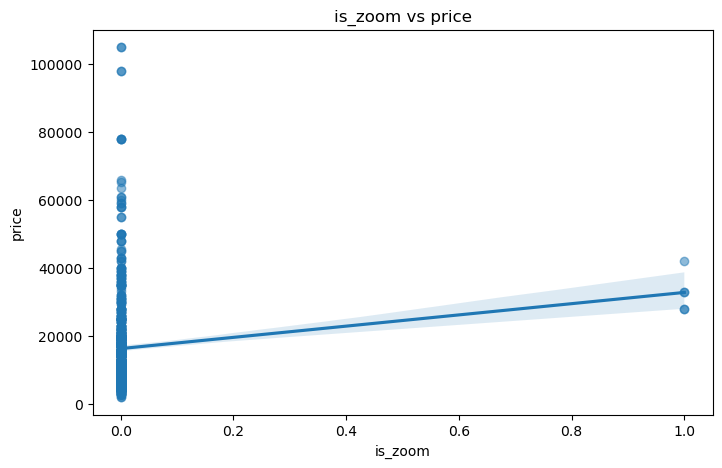


BIVARIATE ANALYSIS : is_5g vs price

Correlation : 0.317


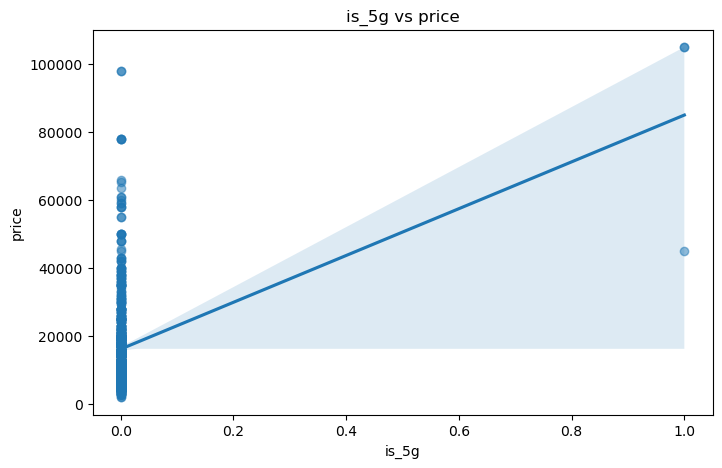


BIVARIATE ANALYSIS : review_count vs price

Correlation : -0.171


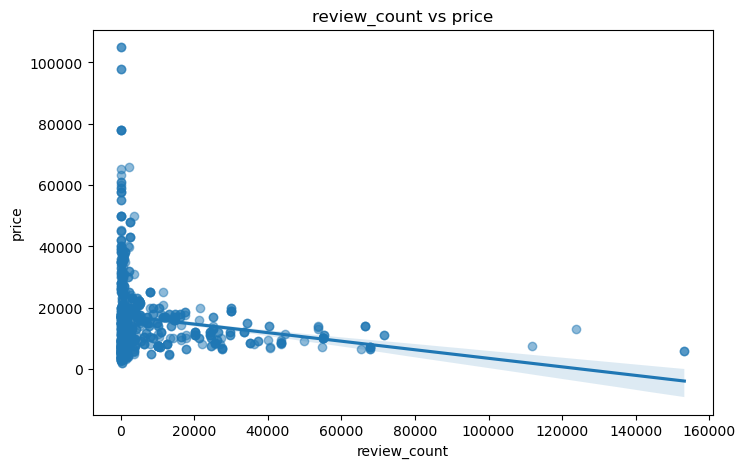


BIVARIATE ANALYSIS : processor_brand vs price
                 count          mean   median   min     max
processor_brand                                            
exynos              70  33997.000000  23999.0  5280  104999
snapdragon         409  18296.251834  14999.0  3990   60990
kirin               30  16214.033333  15999.0  7999   26499
mediatek           235  11582.531915   9999.0  2499   29990
other               75   7406.120000   5999.0  2850   41999
unisoc               5   5392.800000   5499.0  3690    6499
spreadtrum          14   4246.785714   3620.0  1999    7499


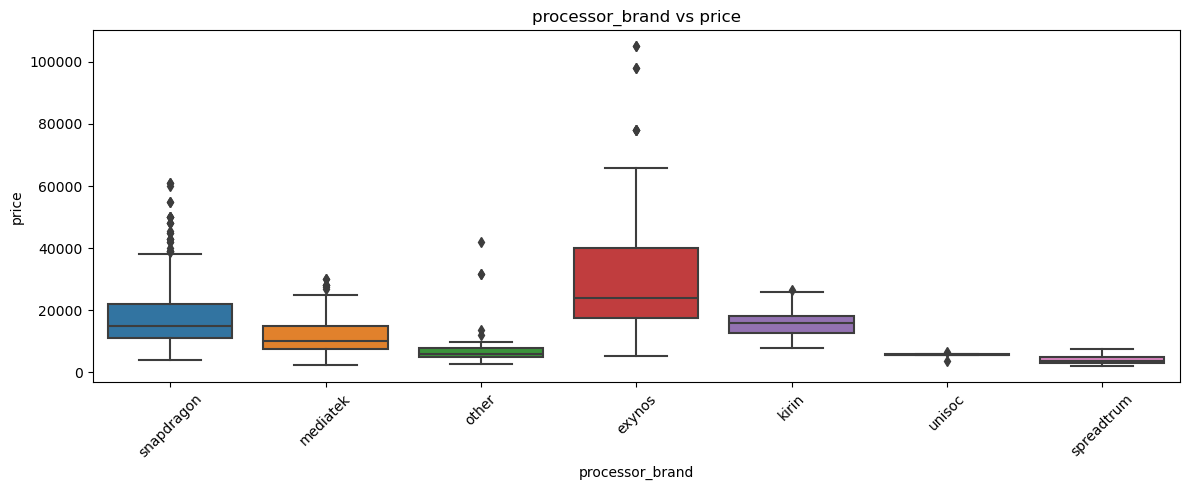


BIVARIATE ANALYSIS : processor_series vs price
                  count          mean   median    min     max
processor_series                                             
8000                  1  49990.000000  49990.0  49990   49990
800                  70  33298.600000  31999.0   8250   60990
p95                   5  28790.000000  27990.0  27990   29990
p90                   1  27490.000000  27490.0  27490   27490
9000                 31  26318.483871  24999.0  14082   65900
700                  86  20849.046512  18499.0  12999   49990
p65                   7  17847.142857  18990.0  14990   19990
g90                  18  16359.555556  16994.0  12999   18999
p70                  29  15957.689655  16990.0   8499   24990
g85                   8  15868.000000  15877.5  13999   17498
7000                 10  15317.900000  18450.0   5280   19900
p10                   2  14499.000000  14499.0   7499   21499
600                 133  14405.112782  11999.0   7339   39000
unknown             27

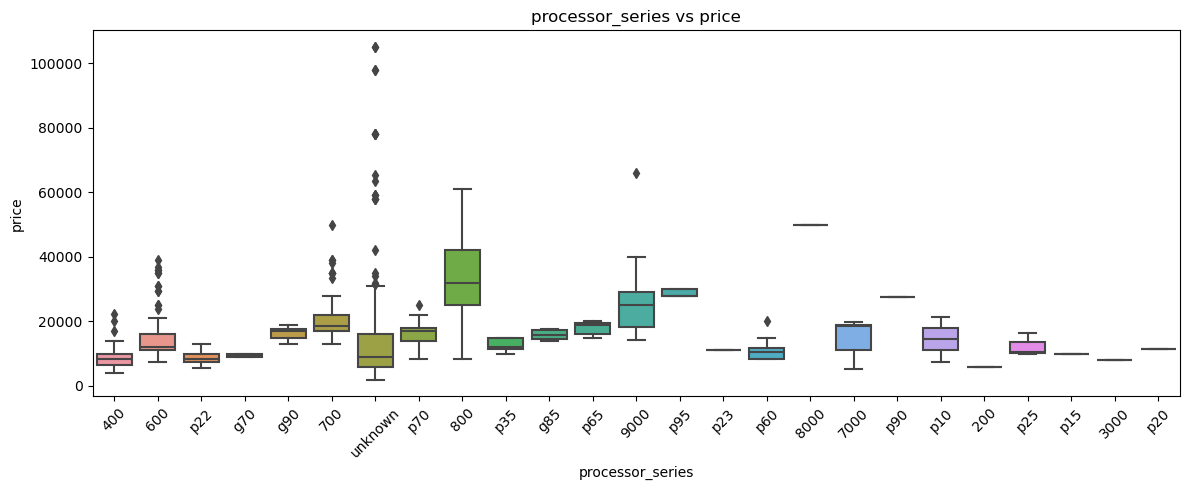


BIVARIATE ANALYSIS : processor_type vs price
                count          mean   median    min     max
processor_type                                             
gaming            112  27370.348214  22999.0  12999   59990
normal            726  14666.214876  11490.0   1999  104999


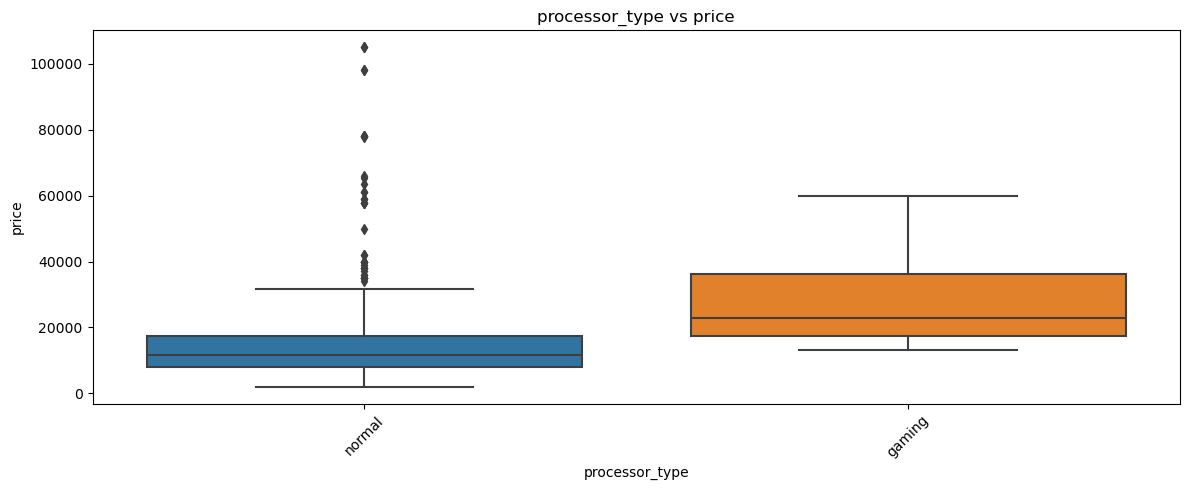


BIVARIATE ANALYSIS : core_type vs price
           count          mean   median   min     max
core_type                                            
unknown      589  17572.264856  14290.0  1999   97999
octa         189  15912.227513  12490.0  4999  104999
quad          60   5927.933333   5499.0  2850   13999


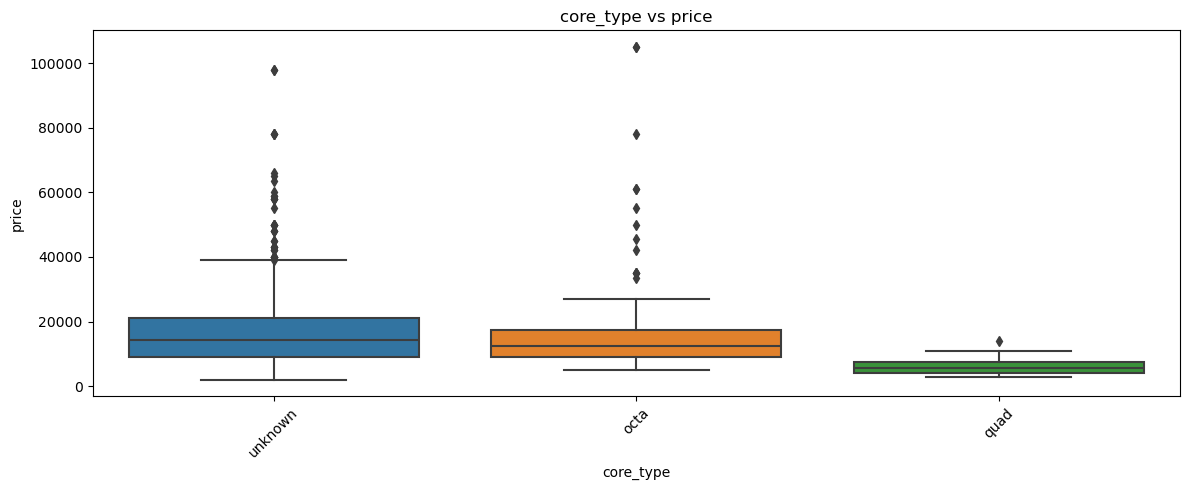


BIVARIATE ANALYSIS : camera_type vs price
             count          mean   median   min     max
camera_type                                            
triple         146  24816.027397  17990.0  4990  104999
quad           188  21520.292553  18926.0  9999   49990
dual           270  14493.966667  11000.0  5699   65200
single         234   9106.089744   6894.5  1999   65900


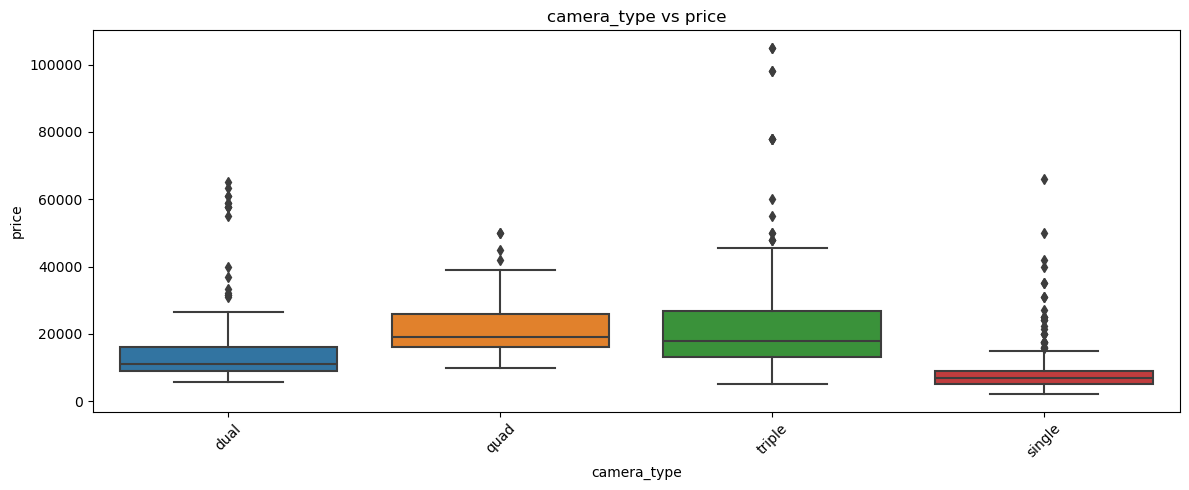


BIVARIATE ANALYSIS : resolution_type vs price
                 count          mean   median   min     max
resolution_type                                            
quad_hd             23  56540.304348  57800.0  5280  104999
full_hd            395  20205.954430  17499.0  3199   77999
unknown             66  19583.151515  17989.5  2499   49999
hd_plus            248   9991.322581   9744.5  3999   19990
hd                  82   6920.695122   6077.0  2850   22221
fwvga               16   4210.375000   4049.0  2999    6999
wvga                 6   3357.000000   3349.0  1999    5896
hvga                 2   3015.500000   3015.5  2741    3290


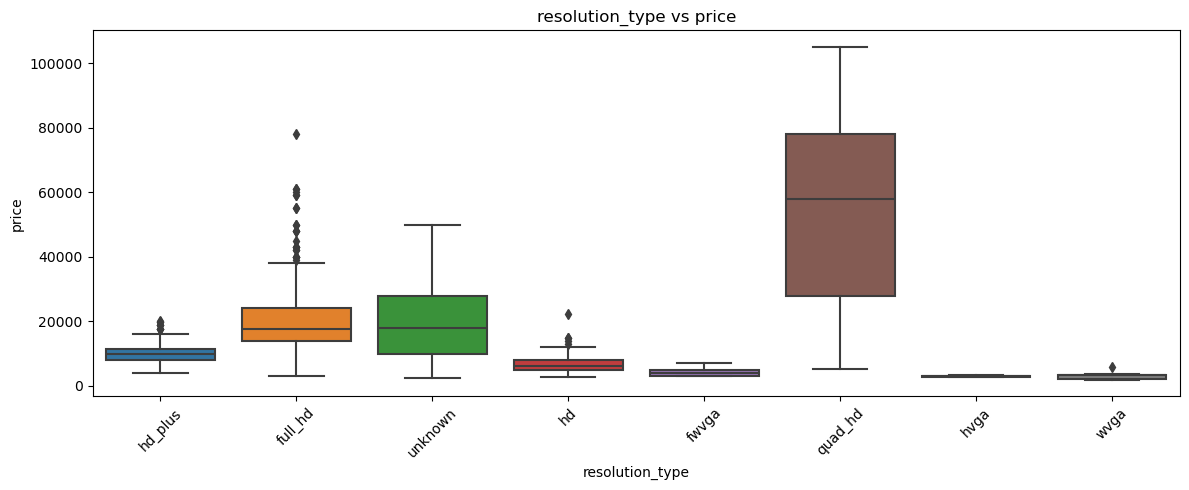


BIVARIATE ANALYSIS : brand vs price
           count          mean   median    min     max
brand                                                 
OnePlus        9  44765.444444  44999.0  34834   59990
iQOO           5  38790.000000  37990.0  34990   44990
Google         4  32999.000000  32999.0  30999   34999
Black          1  31999.000000  31999.0  31999   31999
Samsung      121  28317.214876  19900.0   5280  104999
LG             9  22767.111111  20999.0   4999   54990
Nextbit        1  19999.000000  19999.0  19999   19999
POCO          23  19107.695652  18999.0  13999   22999
OPPO          77  18782.428571  16490.0   6490   60990
Huawei         2  18449.000000  18449.0  16899   19999
Vivo          73  18086.219178  16990.0   7880   49990
Mi            12  17005.333333  14499.0   9188   49990
Realme       134  15946.208955  14999.0   6499   41999
Honor         29  15810.793103  15999.0   7999   26499
MI3            1  13999.000000  13999.0  13999   13999
Motorola       2  13749.0000

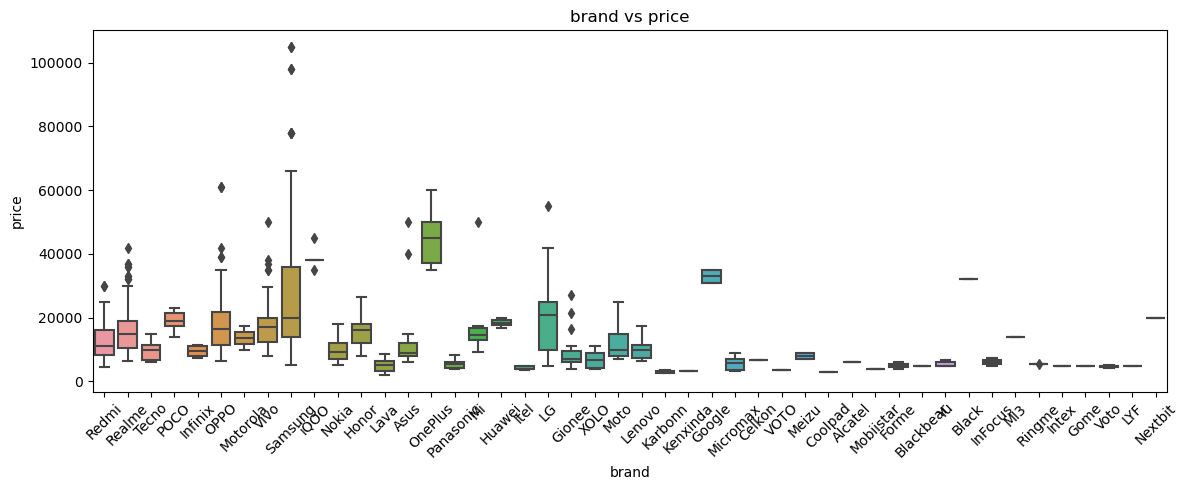


BIVARIATE ANALYSIS : color vs price
                  count     mean   median    min     max
color                                                   
Mystic Bronze         2  91499.0  91499.0  77999  104999
Cosmic Black          2  87999.0  87999.0  77999   97999
Cosmic Gray           2  87999.0  87999.0  77999   97999
Cloud Blue            1  77899.0  77899.0  77899   77899
Mystic Black          2  62494.5  62494.5  19990  104999
...                 ...      ...      ...    ...     ...
Black and Gold        2   3644.5   3644.5   3290    3999
Black & Silver        1   3499.0   3499.0   3499    3499
BLUEM/Blue            1   2999.0   2999.0   2999    2999
White/WHITEM          1   2999.0   2999.0   2999    2999
White and Silver      1   2741.0   2741.0   2741    2741

[275 rows x 5 columns]


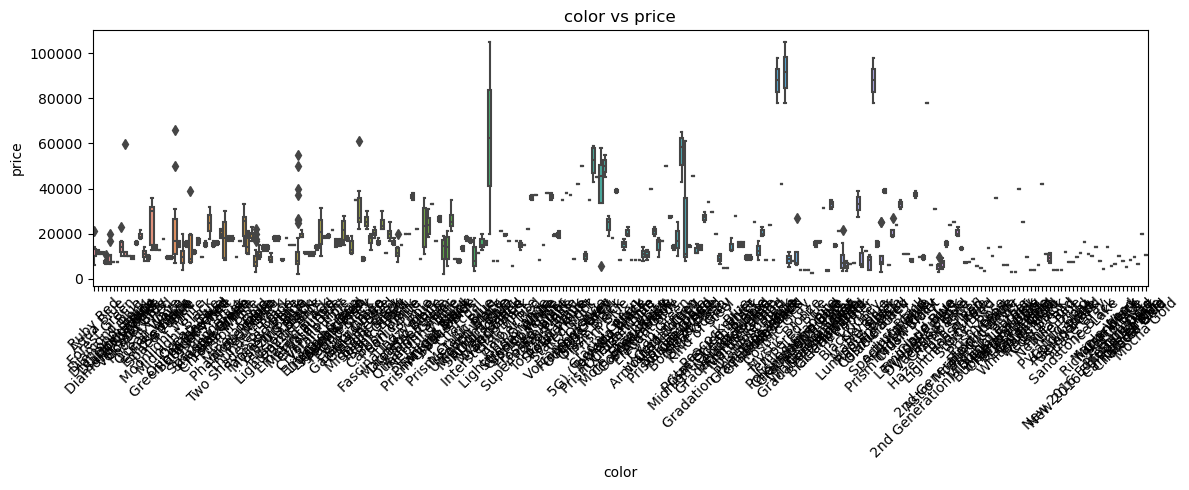


BIVARIATE ANALYSIS : model_name vs price
                                 count           mean    median     min  \
model_name                                                                
Samsung Galaxy Note 20 Ultra 5G      2  104999.000000  104999.0  104999   
Samsung Galaxy S20 Ultra             2   97999.000000   97999.0   97999   
Samsung Galaxy Note 20               1   77999.000000   77999.0   77999   
Samsung Galaxy S20+                  3   77965.666667   77999.0   77899   
Samsung Galaxy S10 Plus              1   65200.000000   65200.0   65200   
...                                ...            ...       ...     ...   
Karbonn A52 plus                     2    3015.500000    3015.5    2741   
Lava A68                             3    2999.000000    2999.0    2999   
Coolpad Mega 5M                      1    2850.000000    2850.0    2850   
Karbonn A40 Indian                   1    2499.000000    2499.0    2499   
Lava Iris Atom X                     2    1999.000000    1

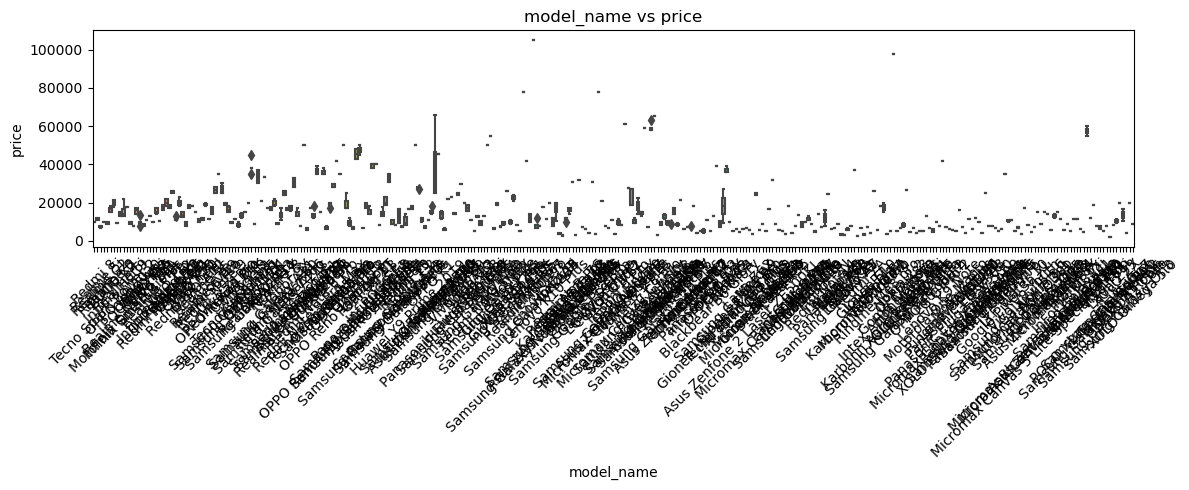

In [61]:

target = "price"
save_path = r"C:\Users\Rithish\Desktop\bivariate_graphs"
os.makedirs(save_path, exist_ok=True)
for col in num_cols:
    print("\n" + "="*60)
    print(f"BIVARIATE ANALYSIS : {col} vs {target}")
    print("="*60)
    corr_value = df_new[col].corr(df_new[target])
    print(f"\nCorrelation : {round(corr_value, 3)}")
    plt.figure(figsize=(8,5))
    sns.regplot(
        x=df_new[col],
        y=df_new[target],
        scatter_kws={'alpha':0.5}
    )
    plt.title(f"{col} vs {target}")
    plt.savefig(
        rf"{save_path}\{col}_vs_price.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()
    plt.close()



for col in cat_col:
    print("\n" + "="*60)
    print(f"BIVARIATE ANALYSIS : {col} vs {target}")
    print("="*60)
    print(
        df_new.groupby(col)[target]
        .agg(['count', 'mean', 'median', 'min', 'max'])
        .sort_values(by='mean', ascending=False)
    ) 
    plt.figure(figsize=(12,5))
    sns.boxplot(
        x=df_new[col],
        y=df_new[target]
    )
    plt.title(f"{col} vs {target}")
    plt.xticks(rotation=45) 
    plt.tight_layout()
    plt.savefig(
        rf"{save_path}\{col}_vs_price.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()
    plt.close()

### battery_capacity vs price
**Relationship**
* Moderate Positive Relationship

**Observation**
* As battery capacity increases, price also slightly increases.
* Most expensive phones contain batteries around 4000–5000mAh.
* Relationship is not perfectly linear because some budget phones also provide large batteries.

**Business Insight**
* Battery capacity contributes to price, but it is not the only deciding factor.
* Brands now provide high battery even in mid-range devices.

### display_size_inch vs price
**Relationship**
* Strong Positive Relationship

**Observation**
* Larger displays generally have higher prices.
* Phones above 6.5 inches are mostly premium or mid-premium devices.
* Small display phones belong mainly to budget segments.

**Business Insight**
* Customers prefer larger displays for multimedia and gaming.
* Premium smartphones focus heavily on bigger displays.

### ram_gb vs price
**Relationship**
* Strong Positive Relationship

**Observation**
* Price increases significantly as RAM increases.
* 8GB and 12GB RAM phones belong mostly to premium categories.
* Low RAM phones remain in lower price ranges.

**Business Insight**
* RAM is one of the strongest pricing factors in smartphones.
* Higher RAM configurations directly indicate premium positioning.

### rom_gb vs price
**Relationship**
* strong Positive Relationship

**Observation**
* Higher internal storage strongly increases smartphone price.
* 256GB and 512GB variants are mostly expensive devices.
* 64GB storage dominates budget and mid-range phones.

**Business Insight**
* Storage capacity strongly affects pricing strategy.
* Premium smartphones focus on higher storage variants.

### front_camera vs price
**Relationship**
* Moderate Positive Relationship

**Observation**
* Higher selfie camera MP generally increases price.
* Premium selfie-focused phones show higher prices.
* Relationship contains some spread and outliers.

**Business Insight**
* Front camera quality contributes to smartphone pricing.
* Selfie features are important in mid-premium segments.

### rear_cam_1 vs price
**Relationship**
* Strong Positive Relationship

**Observation**
* Higher primary rear camera MP increases price.
* 48MP and 64MP cameras appear frequently in higher-priced phones.
* 108MP cameras belong mainly to premium devices.

**Business Insight**
* Camera quality is a major selling point in smartphones.
* Premium phones focus heavily on high-resolution main cameras.

### rating vs price
**Relationship**
* Moderate Positive Relationship

**observation**
* Higher-rated phones generally have higher prices.
* Premium devices tend to receive better customer ratings.

**Business Insight**
* Better product quality and experience increase customer satisfaction.

### camera_type vs price
**Relationship**
* Moderate Positive Relationship

**Observation**
* Triple and quad-camera phones generally have higher prices.
* Single-camera phones mostly belong to budget ranges.

**Business Insight**
* Multi-camera systems increase smartphone market value.

### resolution_type vs price
**Relationship**
* Strong Categorical Relationship

**Observation**
* uad HD displays belong mostly to premium smartphones.
* HD and FWVGA displays appear mainly in budget phones.

**Business Insight**
* Display quality strongly affects smartphone pricing.

### brand vs price
**Relationship**
* Strong Categorical Relationship

**Observation**
* Apple-like premium brands are absent, but Samsung, OnePlus, and Google variants appear costlier.
* Brands like Lava, Micromax, and Karbonn belong mostly to lower price ranges.

**Business Insight**
* Brand reputation strongly influences smartphone pricing strategy.

### Multivariate Analysis

In [62]:
corr_matrix = num_cols.corr()

In [63]:
corr_matrix

,price,rating,rear_cam_1,rear_cam_2,rear_cam_3,rear_cam_4,front_camera,rear_camera_count,battery_capacity,display_size_inch,...,is_pro,is_plus,is_max,is_ultra,is_lite,is_prime,is_core,is_zoom,is_5g,review_count
price,1.000000,0.441990,0.549360,0.683156,0.578605,0.241662,0.441981,0.404045,0.230259,0.450062,...,0.087590,0.065363,-0.123071,0.455026,0.114048,-0.019360,-0.068573,0.098257,0.317487,-0.170824
rating,0.441990,1.000000,0.399945,0.416020,0.291930,0.241449,0.413040,0.503415,0.548109,0.701951,...,0.193354,-0.081071,-0.185484,0.002531,0.023081,0.010601,-0.005877,0.004010,0.015797,0.205557
rear_cam_1,0.549360,0.399945,1.000000,0.653917,0.552818,0.515119,0.572901,0.704851,0.402463,0.571095,...,0.252548,-0.065401,-0.125851,0.271676,-0.055727,-0.044988,-0.084772,0.127453,0.177285,-0.132980
rear_cam_2,0.683156,0.416020,0.653917,1.000000,0.565451,0.434533,0.573086,0.704887,0.367800,0.561685,...,0.198909,-0.033029,-0.123978,0.360969,0.046388,-0.024535,-0.089281,0.068389,0.094103,-0.122204
rear_cam_3,0.578605,0.291930,0.552818,0.565451,1.000000,0.363717,0.471451,0.600649,0.294099,0.433294,...,0.150149,0.109474,-0.104167,0.204638,0.070292,-0.030864,-0.054473,0.137292,0.183023,-0.180849
rear_cam_4,0.241662,0.241449,0.515119,0.434533,0.363717,1.000000,0.382059,0.695422,0.290074,0.326563,...,0.130118,-0.100189,-0.075450,-0.032284,-0.086671,-0.032284,-0.042784,0.068472,0.005773,-0.107145
front_camera,0.441981,0.413040,0.572901,0.573086,0.471451,0.382059,1.000000,0.588130,0.338596,0.550892,...,0.208546,-0.067238,-0.125848,0.077256,0.174474,0.064159,-0.095990,0.118245,-0.017343,-0.122850
rear_camera_count,0.404045,0.503415,0.704851,0.704887,0.600649,0.695422,0.588130,1.000000,0.560013,0.694919,...,0.222096,-0.092686,-0.150815,0.040939,-0.003725,-0.021437,-0.111073,0.101622,0.053428,-0.099963
battery_capacity,0.230259,0.548109,0.402463,0.367800,0.294099,0.290074,0.338596,0.560013,1.000000,0.783995,...,0.103714,-0.016253,-0.068475,0.066825,-0.061114,-0.009004,-0.126394,0.021842,0.038681,0.057584
display_size_inch,0.450062,0.701951,0.571095,0.561685,0.433294,0.326563,0.550892,0.694919,0.783995,1.000000,...,0.205145,-0.056427,-0.189774,0.101691,0.015968,0.006448,-0.164352,0.067579,0.071105,-0.051211


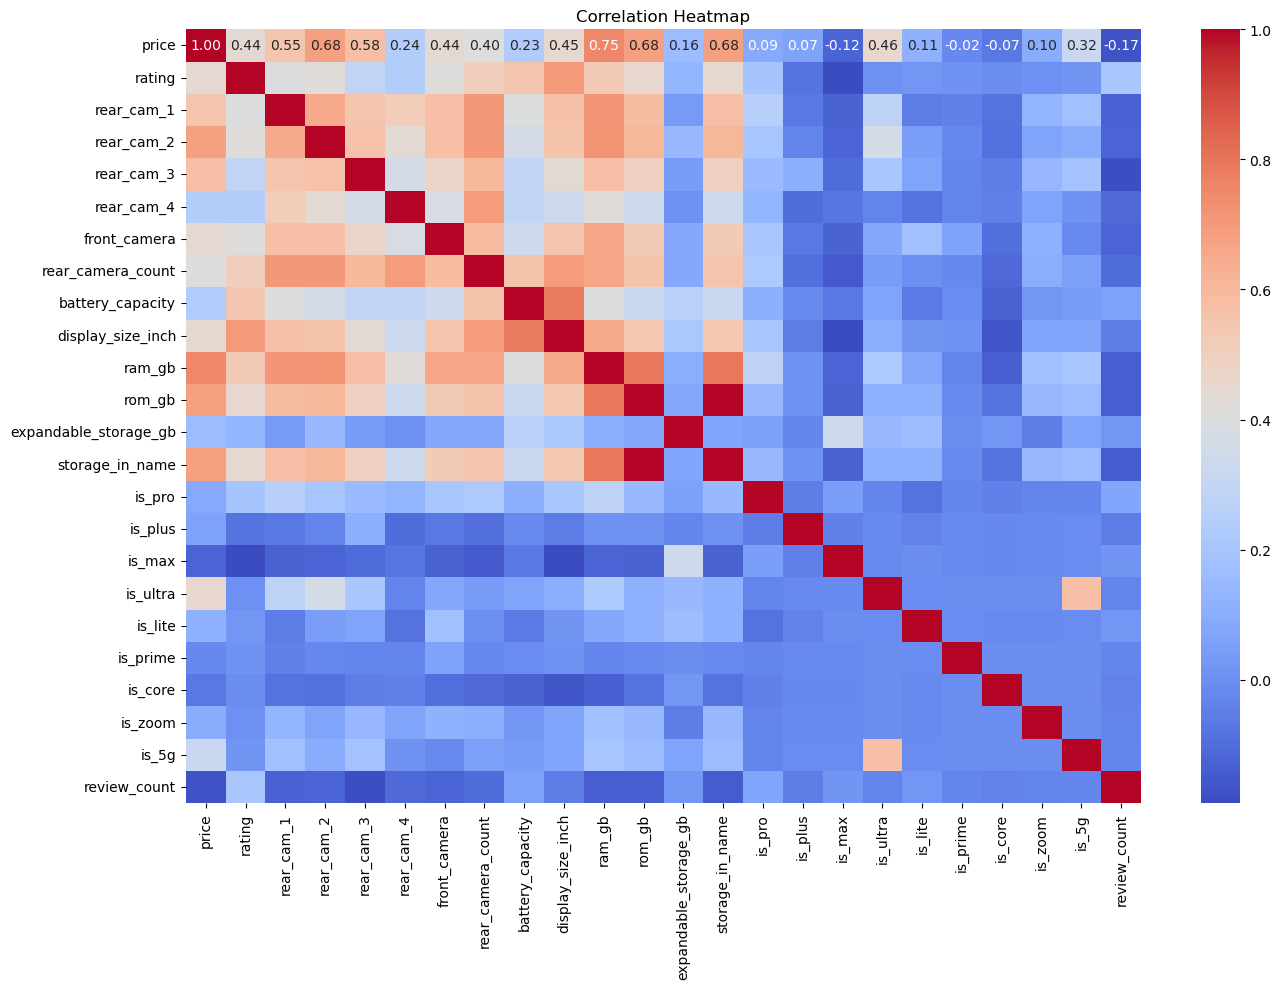

In [64]:
plt.figure(figsize=(14,10))

# heatmap
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.savefig(
        rf"{save_path}\{col}_vs_price.png",
        dpi=300,
        bbox_inches="tight"
    )
plt.show()

In [65]:
df_new.isnull().sum()

price                     0
rating                    8
processor_brand           0
processor_series          0
processor_type            0
core_type                 0
rear_cam_1                0
rear_cam_2                0
rear_cam_3                0
rear_cam_4                0
front_camera             24
rear_camera_count         0
camera_type               0
battery_capacity          0
display_size_inch         0
resolution_type           0
ram_gb                    0
rom_gb                    0
expandable_storage_gb     0
brand                     0
color                     0
storage_in_name           2
model_name                0
is_pro                    0
is_plus                   0
is_max                    0
is_ultra                  0
is_lite                   0
is_prime                  0
is_core                   0
is_zoom                   0
is_5g                     0
review_count              0
dtype: int64

In [66]:
df_new["front_camera"] = df_new["front_camera"].fillna(
    df_new["front_camera"].median()
)

In [67]:
df_new.head()

,price,rating,processor_brand,processor_series,processor_type,core_type,rear_cam_1,rear_cam_2,rear_cam_3,rear_cam_4,...,is_pro,is_plus,is_max,is_ultra,is_lite,is_prime,is_core,is_zoom,is_5g,review_count
0,9999,4.4,snapdragon,400,normal,unknown,12.0,2.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,55078.0
1,10999,4.5,snapdragon,600,normal,unknown,12.0,8.0,2.0,2.0,...,0,0,0,0,0,0,0,0,0,20062.0
2,11999,4.5,snapdragon,600,normal,unknown,12.0,8.0,2.0,2.0,...,0,0,0,0,0,0,0,0,0,20062.0
3,11999,4.5,snapdragon,600,normal,unknown,12.0,8.0,2.0,2.0,...,0,0,0,0,0,0,0,0,0,20062.0
4,7499,4.4,mediatek,p22,normal,octa,13.0,2.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,10091.0


In [68]:
# x is a feature 
x = df_new.drop("price", axis=1)

# y is the target variable 
y = df_new["price"]


In [69]:
drop_cols = [
    "color",
    "model_name",
    "storage_in_name"
]

In [70]:
df_new.drop([
    "color",
    "model_name",
    "storage_in_name"
],axis=1,inplace=True)

In [71]:
df_new.head()

,price,rating,processor_brand,processor_series,processor_type,core_type,rear_cam_1,rear_cam_2,rear_cam_3,rear_cam_4,...,is_pro,is_plus,is_max,is_ultra,is_lite,is_prime,is_core,is_zoom,is_5g,review_count
0,9999,4.4,snapdragon,400,normal,unknown,12.0,2.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,55078.0
1,10999,4.5,snapdragon,600,normal,unknown,12.0,8.0,2.0,2.0,...,0,0,0,0,0,0,0,0,0,20062.0
2,11999,4.5,snapdragon,600,normal,unknown,12.0,8.0,2.0,2.0,...,0,0,0,0,0,0,0,0,0,20062.0
3,11999,4.5,snapdragon,600,normal,unknown,12.0,8.0,2.0,2.0,...,0,0,0,0,0,0,0,0,0,20062.0
4,7499,4.4,mediatek,p22,normal,octa,13.0,2.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,10091.0


# Final Conclusion

This project focused on analyzing smartphone specifications and their impact on product pricing. Extensive data cleaning, preprocessing, and feature engineering were performed to transform unstructured smartphone specifications into meaningful analytical features.

The analysis revealed that smartphone price is primarily influenced by hardware specifications such as RAM, internal storage, camera quality, processor type, and display characteristics. Premium smartphones generally combine multiple high-end specifications, while budget smartphones offer limited configurations at lower prices.

The dataset also showed that higher-priced devices tend to provide better overall hardware configurations rather than excelling in a single specification. Therefore, smartphone pricing is determined by the combined effect of multiple features rather than any individual feature alone.


# Feature Engineering Summary

Several new features were extracted from raw text columns to improve data quality and analytical value.

### Processor Features

* processor_brand
* processor_series
* processor_type
* core_type

### Camera Features

* rear_cam_1
* rear_cam_2
* rear_cam_3
* rear_cam_4
* front_camera
* rear_camera_count

### Battery Features

* battery_capacity

### Display Features

* display_size_inch
* resolution_type

### Memory Features

* ram_gb
* rom_gb
* expandable_storage_gb

### Name-Based Features

* brand
* storage_in_name
* model_name
* is_pro
* is_plus
* is_max
* is_ultra
* is_lite
* is_prime
* is_core
* is_zoom
* is_5g

### Review Features

* review_count

These engineered features transformed raw specifications into structured numerical and categorical variables suitable for analysis and future machine learning tasks.


# Correlation Findings & Business Insights

## Key Correlation Findings

* RAM showed the strongest positive correlation with price (0.75).
* ROM showed a strong positive correlation with price (0.68).
* Secondary camera specifications also showed strong correlation with price.
* Primary camera quality demonstrated a moderate-to-strong positive relationship with price.
* Display size and front camera quality showed moderate positive relationships with price.
* Battery capacity showed only a weak positive correlation with price.
* Review count showed a slight negative correlation with price.

## Business Insights

* Premium smartphones are mainly differentiated through higher RAM and storage configurations.
* Better camera systems significantly contribute to higher product pricing.
* Smartphones with larger displays generally belong to higher price segments.
* Battery capacity alone does not significantly increase smartphone price because large batteries are available across both budget and premium segments.
* Budget smartphones tend to generate higher review counts due to greater sales volume and wider market reach.
* Snapdragon-based smartphones dominate the market, indicating strong consumer preference and brand adoption.
* Full HD displays are the most commonly adopted display type across the smartphone market.
* Major brands such as Realme, Samsung, Redmi, OPPO, and Vivo dominate the dataset, reflecting their strong market presence.

## Final Insights

1. RAM is the most influential feature affecting smartphone price.
2. Storage capacity is one of the primary drivers of premium smartphone pricing.
3. Camera quality plays a significant role in smartphone market positioning.
4. Premium smartphones generally combine better RAM, storage, camera, and display specifications together.
5. Smartphone pricing is influenced by a combination of specifications rather than a single feature.
6. Budget devices dominate customer engagement, while premium devices focus on performance and advanced specifications.
7. Feature engineering significantly improved the quality of analysis by converting complex textual specifications into meaningful structured features.
8. The dataset clearly shows distinct segmentation between budget, mid-range, premium, and flagship smartphones.
